# Part I: From VGG to ResNet [30 pts]
Implement and compare VGG-16 (Version C) and ResNet-18 for image classification. Explore advanced techniques to improve model performance and the transition from standard deep CNNs to networks with residual connections.
The expected accuracy is above 75% for the base model and 80% for the improved model.

In [1]:
import kagglehub
itsahmad_indoor_scenes_cvpr_2019_path = kagglehub.dataset_download('itsahmad/indoor-scenes-cvpr-2019')
print('Data source import complete.')


100%|██████████| 2.34G/2.34G [07:34<00:00, 5.51MB/s]

Extracting files...


## Step 1: Data preparation

1. Load CNN dataset.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import time

In [1]:

dataset_path = "/kaggle/input/cnn-dataset"
# dataset_path = "cnn_part_2_dataset"
classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}

Analyze the dataset.

In [2]:
print("Dataset Description:")
print(f"- Contains {len(classes)} classes: {classes}")
print(f"- Total images: {sum(class_counts.values())}")
print(f"- Class distribution: {class_counts}")

Dataset Description:
- Contains 3 classes: ['dogs', 'food', 'vehicles']
- Total images: 30000
- Class distribution: {'dogs': 10000, 'food': 10000, 'vehicles': 10000}


<span style='color:green'>### YOUR ANSWER ###</span>

The dataset is a well balanced dataset consisting images belonging to 3 classes - dogs, food and vehicles with each class consisting of 10000 images. 

2.	Create at least three different visualizations to explore the dataset. Provide a short description explaining what each visualization shows. 

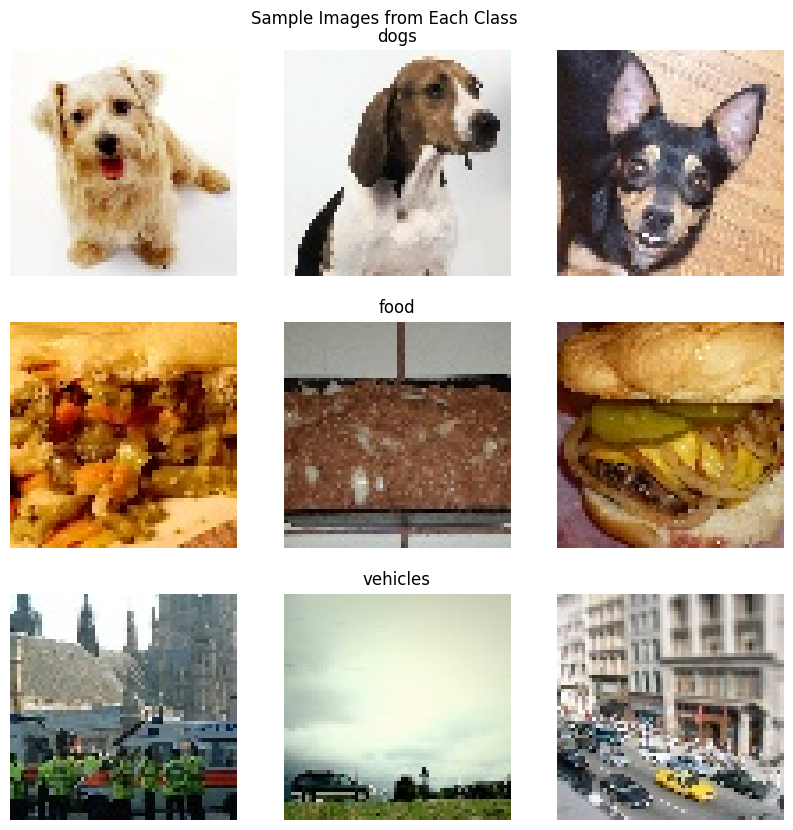

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


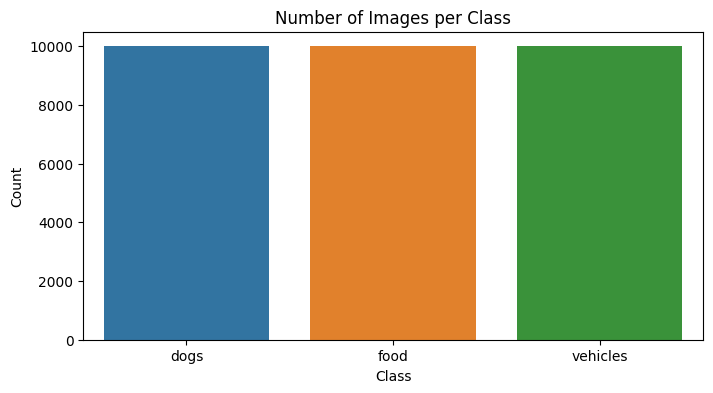

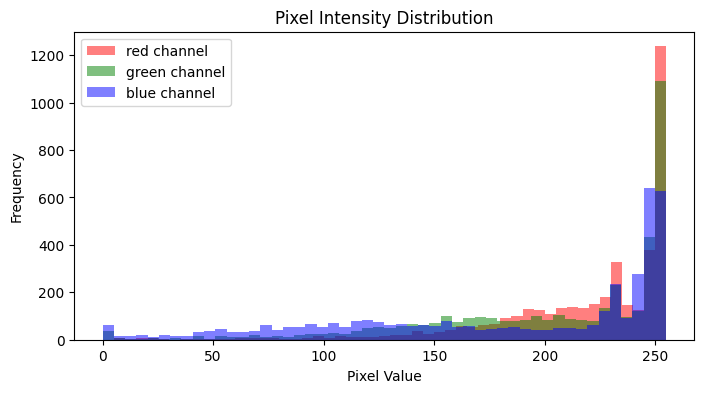

In [3]:
# Sample images grid
plt.figure(figsize=(10, 10))
for i, cls in enumerate(classes):
    img_files = os.listdir(os.path.join(dataset_path, cls))[:3]
    for j, img_file in enumerate(img_files):
        img = Image.open(os.path.join(dataset_path, cls, img_file))
        plt.subplot(3, 3, i*3 + j + 1)
        plt.imshow(img)
        plt.title(f"{cls}" if j == 1 else "")
        plt.axis('off')
plt.suptitle("Sample Images from Each Class", y=0.92)
plt.show()

# Class distribution
plt.figure(figsize=(8, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Pixel value histogram
sample_img = np.array(Image.open(os.path.join(dataset_path, classes[0], os.listdir(os.path.join(dataset_path, classes[0]))[0])))
plt.figure(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.hist(sample_img[:,:,i].ravel(), bins=50, color=colors[i], alpha=0.5, label=f'{colors[i]} channel')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

<span style='color:green'>### YOUR ANSWER ###</span>

- Some images display the object of interest clearly while some other images have background clutter and occulusion changes which can be difficult for the model to distingush and identify the object of interest
- The image dataset consists of equal number of images in each of the classes as seen in the distribution class graph, this reduces the risk of bias in model training
- From the channel distribution graph, we can see that the blue channel holds a broader range of intensity values compared to the red and green channels. Additionally, the red channel shows the highest peak intensity values. 


3. Preprocess the dataset.

In [4]:
class CNNImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.images = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for img_name in os.listdir(cls_dir):
                self.images.append((os.path.join(cls_dir, img_name), self.class_to_idx[cls]))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path, label = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

4. Split the dataset into training, testing, and validation sets.

In [5]:
full_dataset = CNNImageDataset(dataset_path)
train_idx, test_idx = train_test_split(range(len(full_dataset)), test_size=0.3, stratify=[label for _, label in full_dataset.images])
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, stratify=[full_dataset.images[i][1] for i in train_idx])

train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
val_dataset = torch.utils.data.Subset(full_dataset, val_idx)
test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

batch_sizes = [64, 128]
train_loader = DataLoader(train_dataset, batch_size=batch_sizes[0], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_sizes[0], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_sizes[0], shuffle=False)

## Step 2: Implementing VGG

1. Implement the VGG-16 (Version C) architecture.
2. Use dropout and learning rate scheduler. Experiment with weight initialization strategies.

In [6]:
import torch.nn as nn
import torch.nn.init as init

class VGG16BaseModel(nn.Module):
    def __init__(self, num_classes=3, init_method='xavier'):
        super(VGG16BaseModel, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )
        
        self._initialize_weights(init_method)
    
    def _initialize_weights(self, method):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                if method == 'xavier':
                    init.xavier_normal_(m.weight)
                elif method == 'he':
                    init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, 0, 0.01)
                init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


Adding dropout and batch normalization

In [7]:
import torch.nn as nn
import torch.nn.init as init

class VGG16ImprovedModel(nn.Module):
    def __init__(self, num_classes=3, init_method='xavier'):
        super(VGG16ImprovedModel, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )
        
        # Weight initialization
        self._initialize_weights(init_method)
    
    def _initialize_weights(self, method):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                if method == 'xavier':
                    init.xavier_normal_(m.weight)
                elif method == 'he':
                    init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, 0, 0.01)
                init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


3. Train your VGG-16 model.
4. Apply regularization and overfitting prevention techniques.

In [23]:
early_stopping_threshold = 5
def train_model(model, train_loader, val_loader, criterion, optimizer,model_name_prefix, scheduler=None, num_epochs=25, device='cuda'):
    os.makedirs("saved_models", exist_ok=True)
    model = model.to(device)
    vgg_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'best_acc': 0}
    best_acc = 0.0
    for epoch in tqdm(range(num_epochs)):
        start_time = time.time()
        model.train()
        
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total
        
        val_loss, val_acc, val_preds, val_labels = evaluate_model(model, val_loader, criterion, device)
        
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_acc)
            else:
                scheduler.step()
        
        vgg_history['train_loss'].append(train_loss)
        vgg_history['val_loss'].append(val_loss)
        vgg_history['train_acc'].append(train_acc)
        vgg_history['val_acc'].append(val_acc)
        

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            vgg_history['best_acc'] = best_acc
            # print(f"Best model's accuracy is:{val_acc}")
            torch.save(model.state_dict(), model_name_prefix)
        else:
            epochs_with_no_improvement += 1
        end_time = time.time()
        epoch_time = end_time - start_time
       
        
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Time: {epoch_time:.2f} sec')
       
        if epochs_with_no_improvement >= early_stopping_threshold:
            print(f"Early stopping triggered after {epoch+1} epochs. "
                  f"No improvement in validation accuracy for {early_stopping_threshold} epochs.")
            break

    return vgg_history


5. Evaluation and analysis.
6. Save the weights of the trained network.

In [9]:
def evaluate_model(model, loader, criterion, device='cuda'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    loss = running_loss / len(loader.dataset)
    acc = correct / total
    return loss, acc, all_preds, all_labels

def plot_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Training with: Init=xavier, Optimizer=SGD, Batch=64


 20%|██        | 1/5 [03:24<13:37, 204.26s/it]

Best model's accuracy is:0.37166666666666665
Epoch 1/5: Train Loss: 1.0912, Train Acc: 0.3675 | Val Loss: 1.0763, Val Acc: 0.3717, Time: 204.26 sec


 40%|████      | 2/5 [04:12<05:36, 112.22s/it]

Best model's accuracy is:0.7321428571428571
Epoch 2/5: Train Loss: 0.7942, Train Acc: 0.6417 | Val Loss: 0.6661, Val Acc: 0.7321, Time: 47.79 sec


...

Best model's accuracy is:0.784047619047619
Epoch 3/5: Train Loss: 0.5019, Train Acc: 0.7998 | Val Loss: 0.6232, Val Acc: 0.7840, Time: 48.73 sec


 80%|████████  | 4/5 [05:49<01:09, 69.54s/it]

Best model's accuracy is:0.8495238095238096
Epoch 4/5: Train Loss: 0.4317, Train Acc: 0.8323 | Val Loss: 0.4213, Val Acc: 0.8495, Time: 48.56 sec


100%|██████████| 5/5 [06:38<00:00, 79.71s/it]

Best model's accuracy is:0.8657142857142858
Epoch 5/5: Train Loss: 0.3842, Train Acc: 0.8533 | Val Loss: 0.3542, Val Acc: 0.8657, Time: 49.23 sec


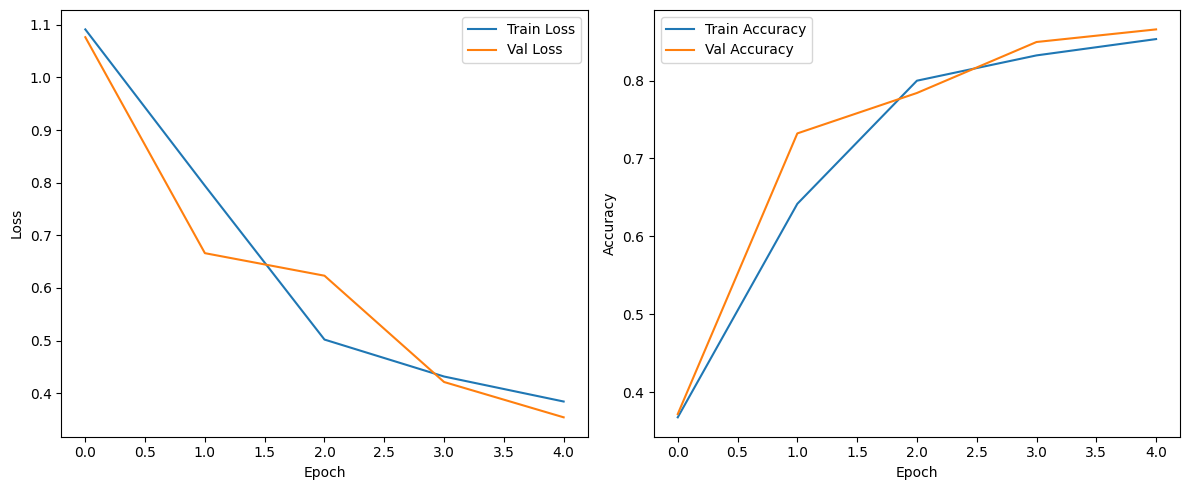

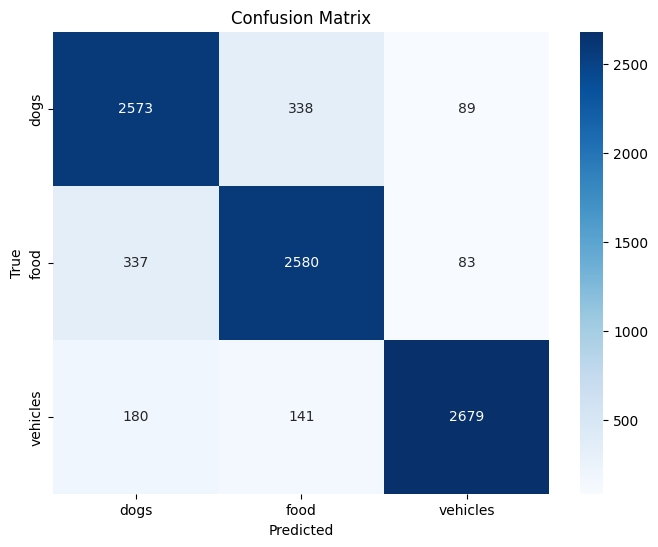

Classification Report:
              precision    recall  f1-score   support

        dogs       0.83      0.86      0.84      3000
        food       0.84      0.86      0.85      3000
    vehicles       0.94      0.89      0.92      3000

    accuracy                           0.87      9000
   macro avg       0.87      0.87      0.87      9000
weighted avg       0.87      0.87      0.87      9000


Training with: Init=xavier, Optimizer=SGD, Batch=128


 20%|██        | 1/5 [00:50<03:22, 50.75s/it]

Best model's accuracy is:0.3333333333333333
Epoch 1/5: Train Loss: 1.0850, Train Acc: 0.3680 | Val Loss: 1.1192, Val Acc: 0.3333, Time: 50.75 sec


 40%|████      | 2/5 [01:42<02:34, 51.45s/it]

Best model's accuracy is:0.5076190476190476
Epoch 2/5: Train Loss: 1.0668, Train Acc: 0.4324 | Val Loss: 0.9986, Val Acc: 0.5076, Time: 51.94 sec


...

Best model's accuracy is:0.7261904761904762
Epoch 3/5: Train Loss: 0.7673, Train Acc: 0.6638 | Val Loss: 0.6389, Val Acc: 0.7262, Time: 50.73 sec


 80%|████████  | 4/5 [03:23<00:50, 50.87s/it]

Best model's accuracy is:0.8257142857142857
Epoch 4/5: Train Loss: 0.5478, Train Acc: 0.7761 | Val Loss: 0.4714, Val Acc: 0.8257, Time: 50.49 sec


100%|██████████| 5/5 [04:15<00:00, 51.09s/it]

Epoch 5/5: Train Loss: 0.4495, Train Acc: 0.8265 | Val Loss: 0.5027, Val Acc: 0.7917, Time: 51.52 sec


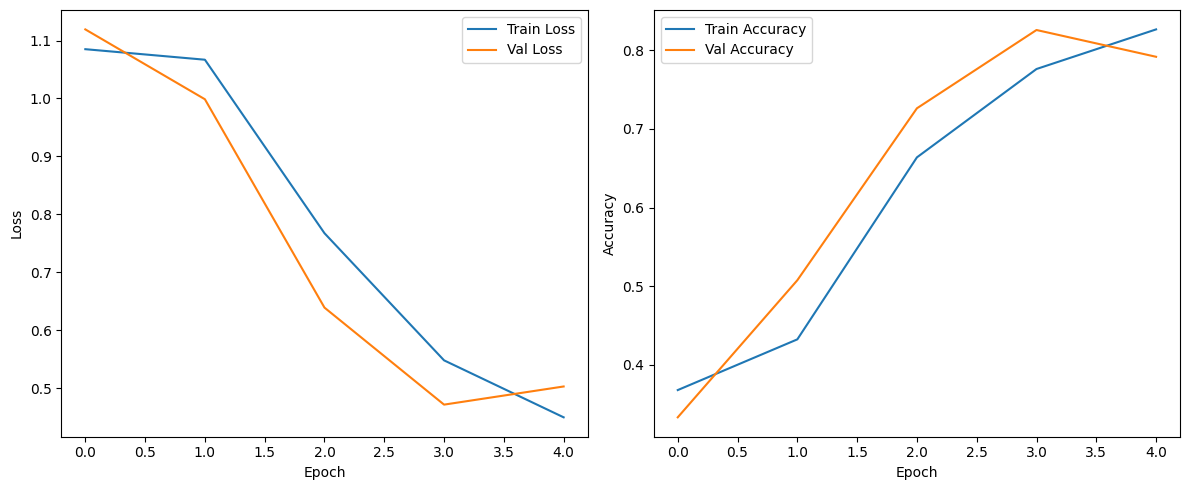

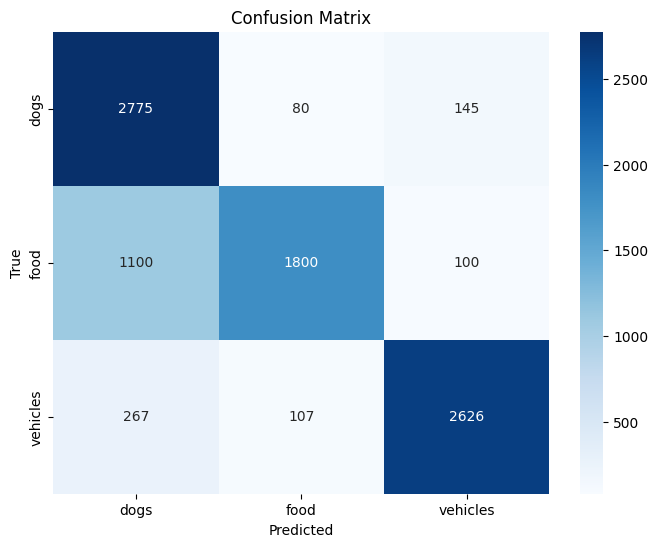

Classification Report:
              precision    recall  f1-score   support

        dogs       0.67      0.93      0.78      3000
        food       0.91      0.60      0.72      3000
    vehicles       0.91      0.88      0.89      3000

    accuracy                           0.80      9000
   macro avg       0.83      0.80      0.80      9000
weighted avg       0.83      0.80      0.80      9000


Training with: Init=xavier, Optimizer=Adam, Batch=64


 20%|██        | 1/5 [00:55<03:42, 55.58s/it]

Best model's accuracy is:0.3333333333333333
Epoch 1/5: Train Loss: 1.2277, Train Acc: 0.3285 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 55.58 sec


 40%|████      | 2/5 [01:49<02:44, 54.79s/it]

Epoch 2/5: Train Loss: 1.0987, Train Acc: 0.3262 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.24 sec


...

 80%|████████  | 4/5 [03:41<00:55, 55.37s/it]

Epoch 4/5: Train Loss: 1.0987, Train Acc: 0.3326 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 55.84 sec


100%|██████████| 5/5 [04:35<00:00, 55.01s/it]

Epoch 5/5: Train Loss: 1.0987, Train Acc: 0.3336 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.03 sec



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


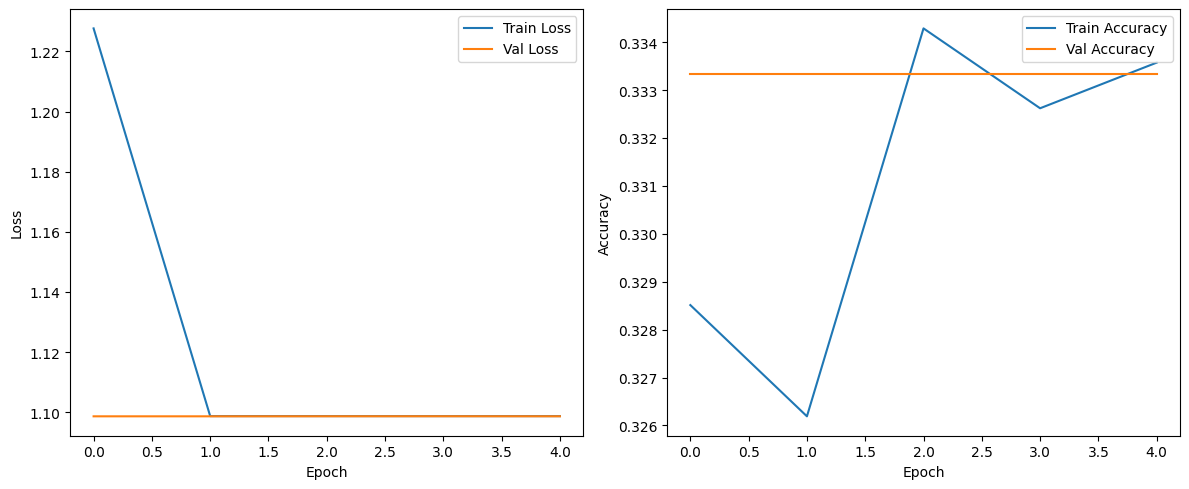

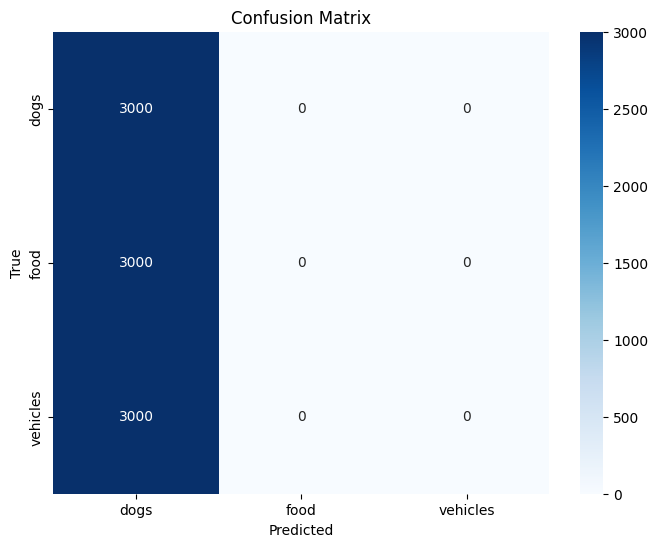

Classification Report:
              precision    recall  f1-score   support

        dogs       0.33      1.00      0.50      3000
        food       0.00      0.00      0.00      3000
    vehicles       0.00      0.00      0.00      3000

    accuracy                           0.33      9000
   macro avg       0.11      0.33      0.17      9000
weighted avg       0.11      0.33      0.17      9000


Training with: Init=xavier, Optimizer=Adam, Batch=128


 20%|██        | 1/5 [00:51<03:26, 51.62s/it]

Best model's accuracy is:0.3333333333333333
Epoch 1/5: Train Loss: 1.5082, Train Acc: 0.3252 | Val Loss: 1.0983, Val Acc: 0.3333, Time: 51.62 sec


 40%|████      | 2/5 [01:42<02:34, 51.37s/it]

Epoch 2/5: Train Loss: 1.1442, Train Acc: 0.3277 | Val Loss: 1.4931, Val Acc: 0.3333, Time: 51.20 sec


...

Epoch 3/5: Train Loss: 1.1065, Train Acc: 0.3355 | Val Loss: 1.0987, Val Acc: 0.3333, Time: 51.59 sec


 80%|████████  | 4/5 [03:25<00:51, 51.35s/it]

Epoch 4/5: Train Loss: 1.1170, Train Acc: 0.3445 | Val Loss: 1.0974, Val Acc: 0.3333, Time: 51.16 sec


100%|██████████| 5/5 [04:17<00:00, 51.42s/it]

Best model's accuracy is:0.6923809523809524
Epoch 5/5: Train Loss: 0.9839, Train Acc: 0.4614 | Val Loss: 0.6531, Val Acc: 0.6924, Time: 51.52 sec


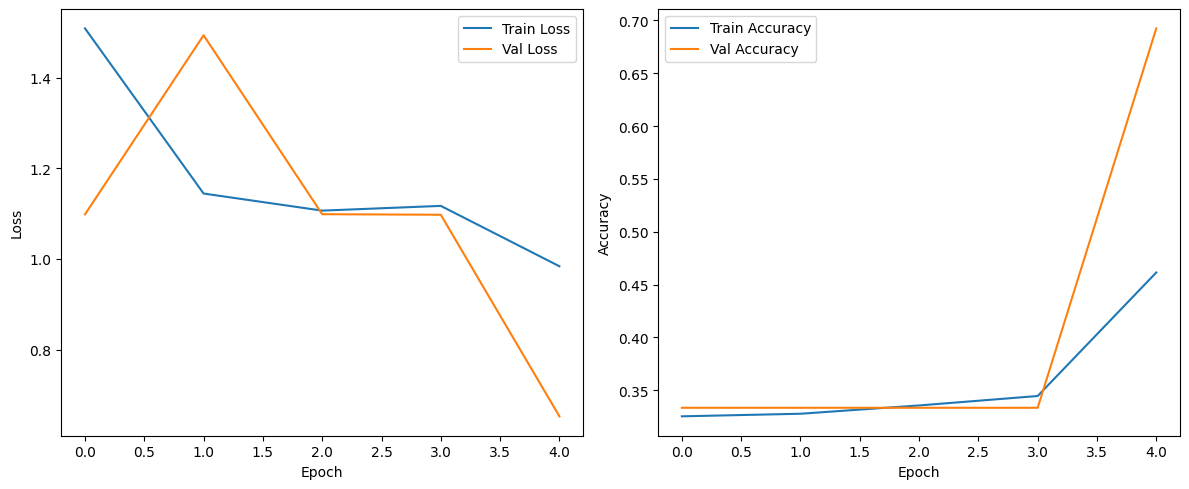

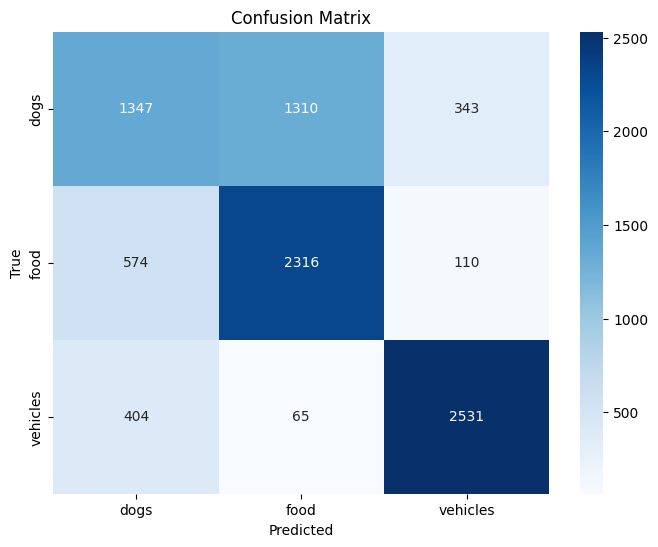

Classification Report:
              precision    recall  f1-score   support

        dogs       0.58      0.45      0.51      3000
        food       0.63      0.77      0.69      3000
    vehicles       0.85      0.84      0.85      3000

    accuracy                           0.69      9000
   macro avg       0.69      0.69      0.68      9000
weighted avg       0.69      0.69      0.68      9000


Training with: Init=he, Optimizer=SGD, Batch=64


 20%|██        | 1/5 [00:49<03:19, 49.87s/it]

Best model's accuracy is:0.7764285714285715
Epoch 1/5: Train Loss: 0.7651, Train Acc: 0.6628 | Val Loss: 0.5739, Val Acc: 0.7764, Time: 49.87 sec


 40%|████      | 2/5 [01:38<02:28, 49.42s/it]

Best model's accuracy is:0.81
Epoch 2/5: Train Loss: 0.4881, Train Acc: 0.8077 | Val Loss: 0.4716, Val Acc: 0.8100, Time: 49.11 sec


...

Best model's accuracy is:0.8552380952380952
Epoch 3/5: Train Loss: 0.4015, Train Acc: 0.8423 | Val Loss: 0.3959, Val Acc: 0.8552, Time: 49.17 sec


 80%|████████  | 4/5 [03:17<00:49, 49.17s/it]

Epoch 4/5: Train Loss: 0.3453, Train Acc: 0.8679 | Val Loss: 0.4088, Val Acc: 0.8457, Time: 48.96 sec


100%|██████████| 5/5 [04:05<00:00, 49.18s/it]

Best model's accuracy is:0.8604761904761905
Epoch 5/5: Train Loss: 0.3115, Train Acc: 0.8849 | Val Loss: 0.3366, Val Acc: 0.8605, Time: 48.80 sec


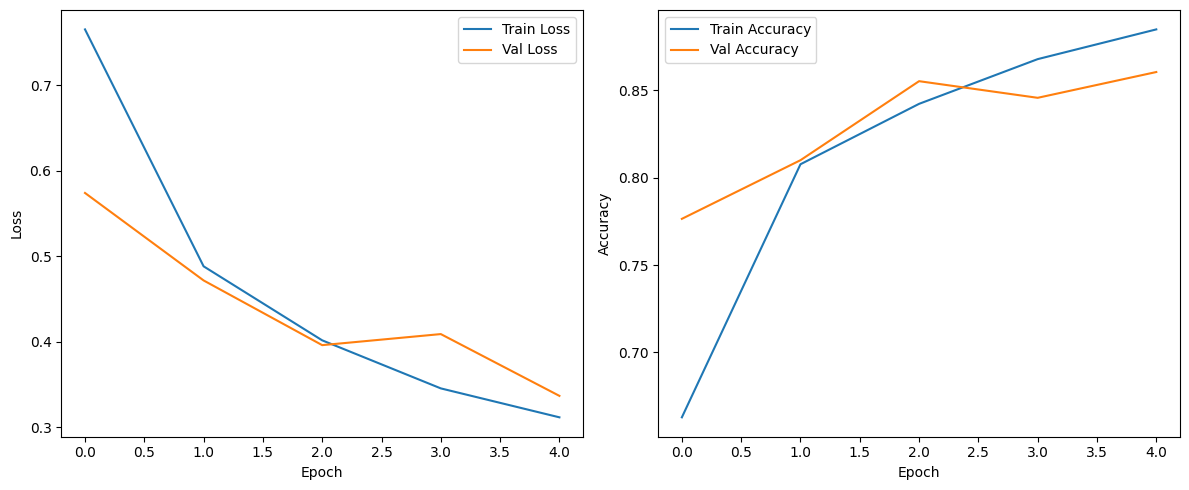

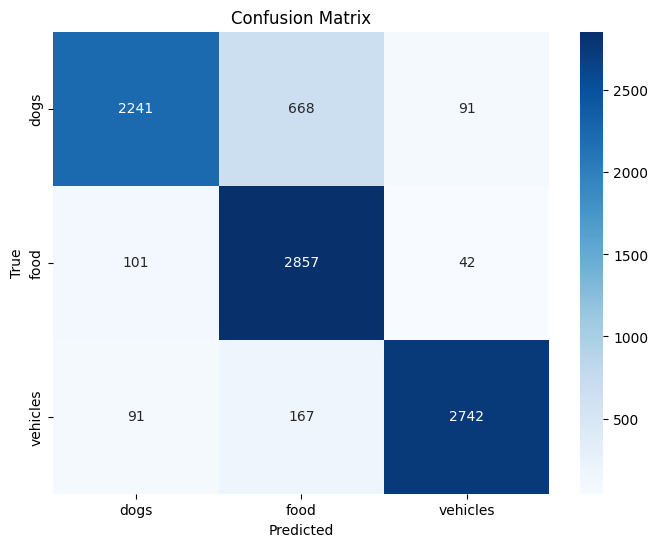

Classification Report:
              precision    recall  f1-score   support

        dogs       0.92      0.75      0.82      3000
        food       0.77      0.95      0.85      3000
    vehicles       0.95      0.91      0.93      3000

    accuracy                           0.87      9000
   macro avg       0.88      0.87      0.87      9000
weighted avg       0.88      0.87      0.87      9000


Training with: Init=he, Optimizer=SGD, Batch=128


 20%|██        | 1/5 [00:49<03:18, 49.58s/it]

Best model's accuracy is:0.7371428571428571
Epoch 1/5: Train Loss: 0.8816, Train Acc: 0.5858 | Val Loss: 0.6764, Val Acc: 0.7371, Time: 49.58 sec


 40%|████      | 2/5 [01:38<02:27, 49.27s/it]

Best model's accuracy is:0.7866666666666666
Epoch 2/5: Train Loss: 0.5421, Train Acc: 0.7861 | Val Loss: 0.5496, Val Acc: 0.7867, Time: 49.05 sec


...

Best model's accuracy is:0.8528571428571429
Epoch 3/5: Train Loss: 0.4434, Train Acc: 0.8278 | Val Loss: 0.3901, Val Acc: 0.8529, Time: 49.48 sec


 80%|████████  | 4/5 [03:17<00:49, 49.31s/it]

Epoch 4/5: Train Loss: 0.3735, Train Acc: 0.8568 | Val Loss: 0.3980, Val Acc: 0.8512, Time: 49.23 sec


100%|██████████| 5/5 [04:06<00:00, 49.32s/it]

Best model's accuracy is:0.861904761904762
Epoch 5/5: Train Loss: 0.3264, Train Acc: 0.8795 | Val Loss: 0.3628, Val Acc: 0.8619, Time: 49.28 sec


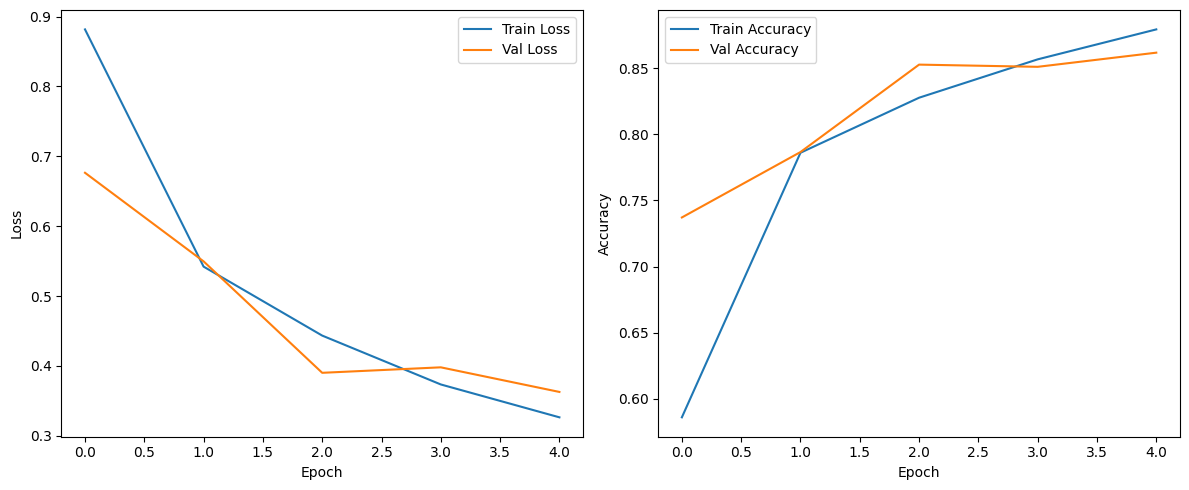

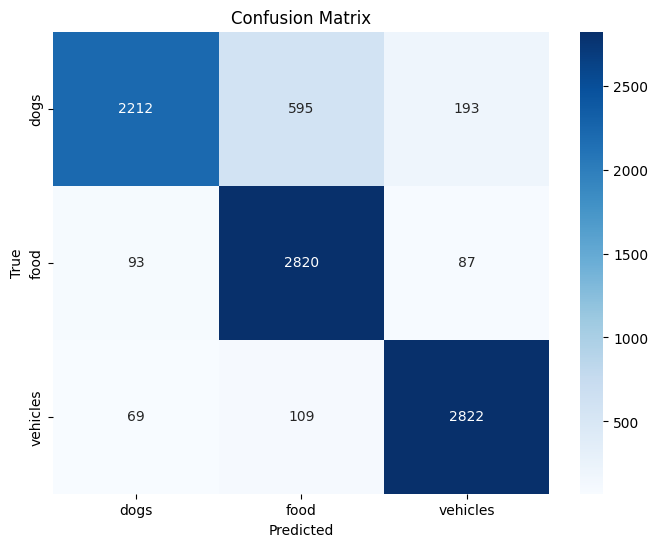

Classification Report:
              precision    recall  f1-score   support

        dogs       0.93      0.74      0.82      3000
        food       0.80      0.94      0.86      3000
    vehicles       0.91      0.94      0.92      3000

    accuracy                           0.87      9000
   macro avg       0.88      0.87      0.87      9000
weighted avg       0.88      0.87      0.87      9000


Training with: Init=he, Optimizer=Adam, Batch=64


 20%|██        | 1/5 [00:54<03:38, 54.65s/it]

Best model's accuracy is:0.3333333333333333
Epoch 1/5: Train Loss: 2.0064, Train Acc: 0.3313 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.65 sec


 40%|████      | 2/5 [01:49<02:43, 54.53s/it]

Epoch 2/5: Train Loss: 1.0987, Train Acc: 0.3295 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.45 sec


...

 80%|████████  | 4/5 [03:37<00:54, 54.27s/it]

Epoch 4/5: Train Loss: 1.0987, Train Acc: 0.3253 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.12 sec


100%|██████████| 5/5 [04:31<00:00, 54.31s/it]

Epoch 5/5: Train Loss: 1.0987, Train Acc: 0.3279 | Val Loss: 1.0986, Val Acc: 0.3333, Time: 54.16 sec



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


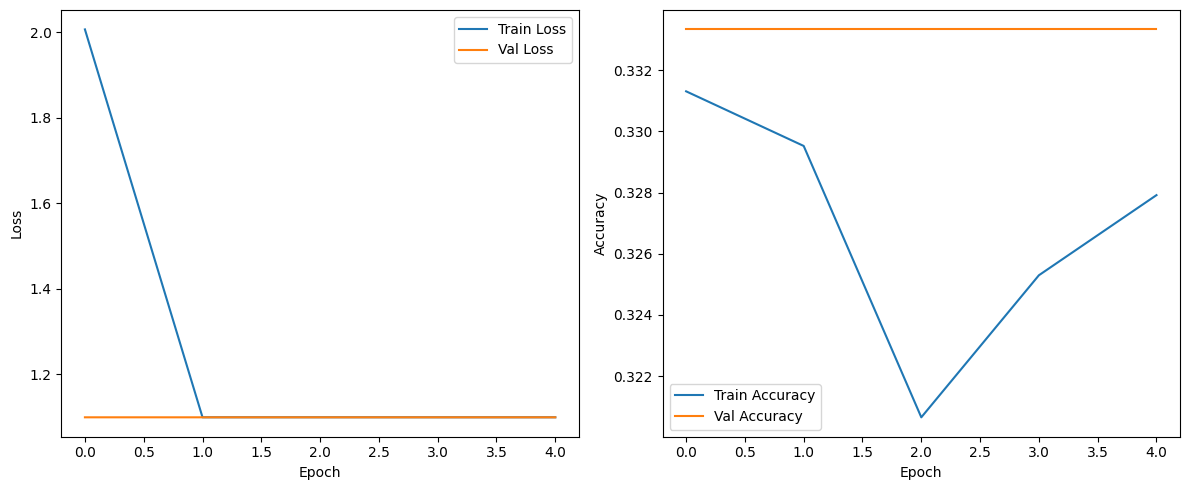

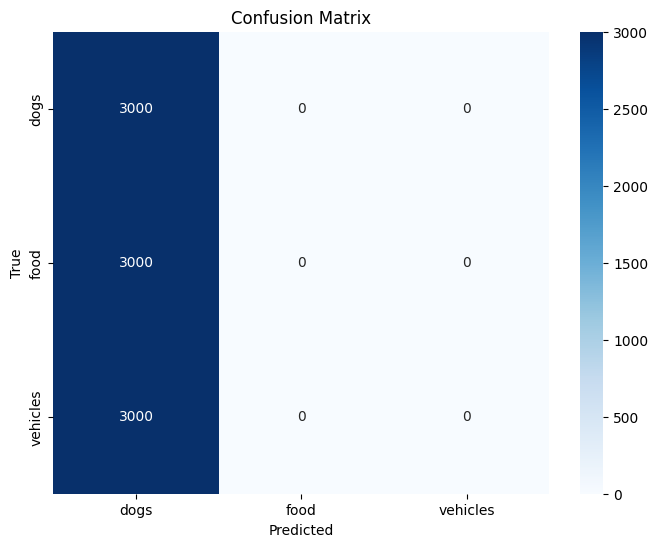

Classification Report:
              precision    recall  f1-score   support

        dogs       0.33      1.00      0.50      3000
        food       0.00      0.00      0.00      3000
    vehicles       0.00      0.00      0.00      3000

    accuracy                           0.33      9000
   macro avg       0.11      0.33      0.17      9000
weighted avg       0.11      0.33      0.17      9000


Training with: Init=he, Optimizer=Adam, Batch=128


 20%|██        | 1/5 [00:52<03:31, 52.79s/it]

Best model's accuracy is:0.7307142857142858
Epoch 1/5: Train Loss: 2.9236, Train Acc: 0.5168 | Val Loss: 0.6333, Val Acc: 0.7307, Time: 52.79 sec


 40%|████      | 2/5 [01:45<02:38, 52.78s/it]

Best model's accuracy is:0.830952380952381
Epoch 2/5: Train Loss: 0.5684, Train Acc: 0.7667 | Val Loss: 0.4575, Val Acc: 0.8310, Time: 52.77 sec


...

Best model's accuracy is:0.8511904761904762
Epoch 3/5: Train Loss: 0.4389, Train Acc: 0.8305 | Val Loss: 0.4179, Val Acc: 0.8512, Time: 51.83 sec


 80%|████████  | 4/5 [03:30<00:52, 52.59s/it]

Best model's accuracy is:0.86
Epoch 4/5: Train Loss: 0.3852, Train Acc: 0.8563 | Val Loss: 0.3874, Val Acc: 0.8600, Time: 52.98 sec


100%|██████████| 5/5 [04:25<00:00, 53.07s/it]

Best model's accuracy is:0.8666666666666667
Epoch 5/5: Train Loss: 0.3206, Train Acc: 0.8826 | Val Loss: 0.3552, Val Acc: 0.8667, Time: 54.97 sec


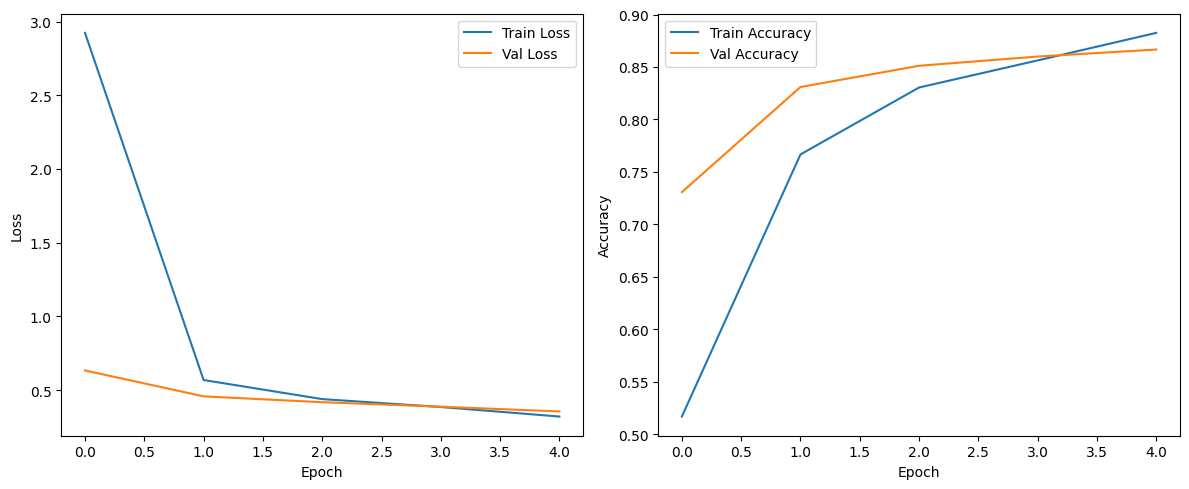

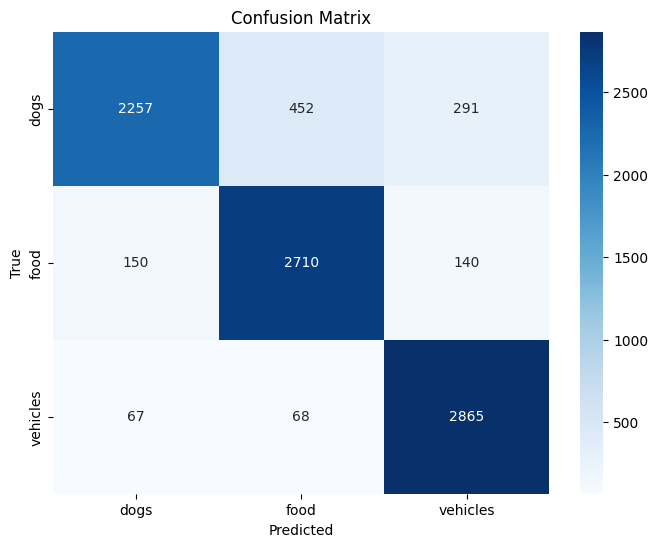

Classification Report:
              precision    recall  f1-score   support

        dogs       0.91      0.75      0.82      3000
        food       0.84      0.90      0.87      3000
    vehicles       0.87      0.95      0.91      3000

    accuracy                           0.87      9000
   macro avg       0.87      0.87      0.87      9000
weighted avg       0.87      0.87      0.87      9000



In [10]:
# Base Model Experimentation
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
epochs = 5
init_methods = ['xavier', 'he']

# Experiment 3: Different batch sizes
batch_sizes = [64, 128]

# Main training loop
results = {}

for init_method in init_methods:
    for opt_name in ['SGD', 'Adam']:
        for batch_size in batch_sizes:
            print(f"\nTraining with: Init={init_method}, Optimizer={opt_name}, Batch={batch_size}")
            

            # Create model
            model = VGG16BaseModel(num_classes=3, init_method=init_method)
            
            # Create optimizer based on opt_name
            if opt_name == 'SGD':
                optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            elif opt_name == 'Adam':
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            
            # Recreate data loaders with current batch size
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
            
            # Add learning rate scheduler
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
            model_name_prefix = 'a1_part2_sarayusi_vishalim_best_vgg_model.pth'
            # Train
            history = train_model(
                model, train_loader, val_loader, criterion, optimizer, model_name_prefix,
                scheduler=scheduler, num_epochs=epochs, device=device, 
            )
            
            # Evaluate
            test_loss, test_acc, test_preds, test_labels = evaluate_model(
                model, test_loader, criterion, device
            )
            
            # Save results
            key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
            results[key] = {
                'vggnet_base_history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }
            
            # Plot results
            plot_history(history)
            plot_confusion_matrix(results[key]['cm'], classes)
            print("Classification Report:")
            print(results[key]['report'])


VGG Base Model Evaluation Results
Test Accuracy: 0.8601111111111112
Test Loss: 0.35288387677404615


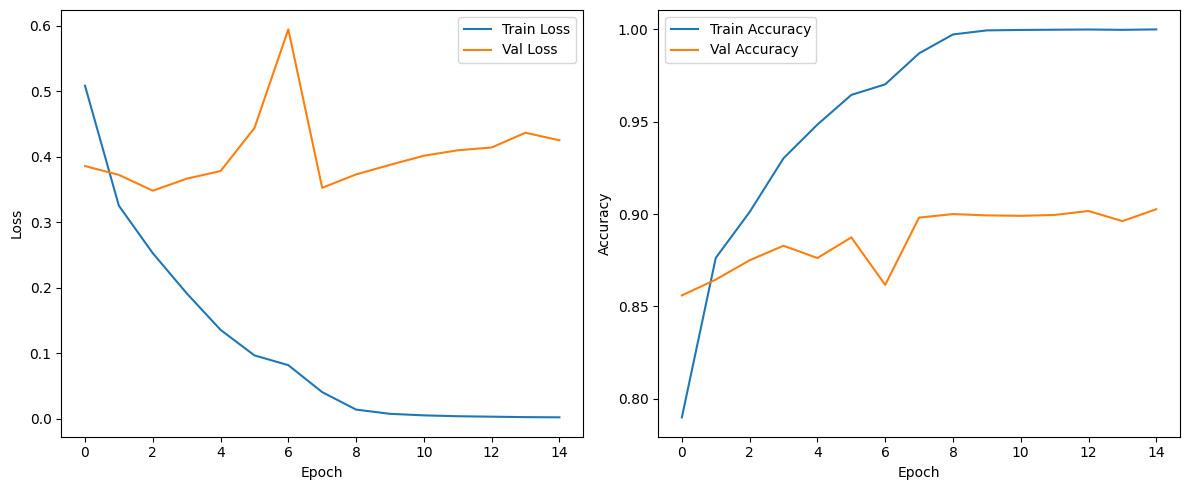

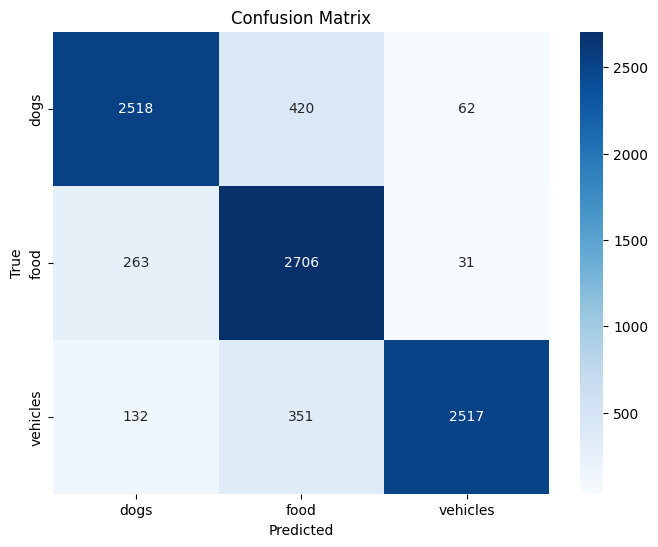

Classification Report:
              precision    recall  f1-score   support

        dogs       0.86      0.84      0.85      3000
        food       0.78      0.90      0.84      3000
    vehicles       0.96      0.84      0.90      3000

    accuracy                           0.86      9000
   macro avg       0.87      0.86      0.86      9000
weighted avg       0.87      0.86      0.86      9000



In [51]:
# best_model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_loss, test_acc, test_preds, test_labels = evaluate_model(
                model, test_loader, criterion, device
            )
            
# Save results
key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
results[key] = {
                'history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }

# Plot results
print("==========================================")
print("VGG Base Model Evaluation Results")
print("==========================================")
print(f"Test Accuracy: {results[key] ['test_acc']}")
print(f"Test Loss: {results[key] ['test_loss']}")
plot_history(history)
plot_confusion_matrix(results[key]['cm'], classes)
print("Classification Report:")
print(results[key]['report'])

Improved model with Regularization

- To mitigate overfitting, we enhanced the VGGNet model by integrating regularization techniques including Dropout and Batch Normalization.
- To prevent the model from converging to suboptimal local minima and to reduce unnecessary training time, we implemented early stopping.


Training with: Init=xavier, Optimizer=SGD, Batch=64


  7%|▋         | 1/15 [01:08<15:58, 68.44s/it]

Epoch 1/15: Train Loss: 0.8352, Train Acc: 0.6814 | Val Loss: 0.5316, Val Acc: 0.7883, Time: 68.44 sec


 13%|█▎        | 2/15 [02:02<13:00, 60.05s/it]

Epoch 2/15: Train Loss: 0.4784, Train Acc: 0.8199 | Val Loss: 0.3669, Val Acc: 0.8588, Time: 54.17 sec


...

Epoch 13/15: Train Loss: 0.0852, Train Acc: 0.9698 | Val Loss: 0.1934, Val Acc: 0.9312, Time: 54.74 sec


 93%|█████████▎| 14/15 [12:58<00:55, 55.43s/it]

Epoch 14/15: Train Loss: 0.0816, Train Acc: 0.9706 | Val Loss: 0.2043, Val Acc: 0.9302, Time: 56.42 sec


100%|██████████| 15/15 [13:53<00:00, 55.59s/it]

Epoch 15/15: Train Loss: 0.0595, Train Acc: 0.9793 | Val Loss: 0.2011, Val Acc: 0.9326, Time: 54.87 sec


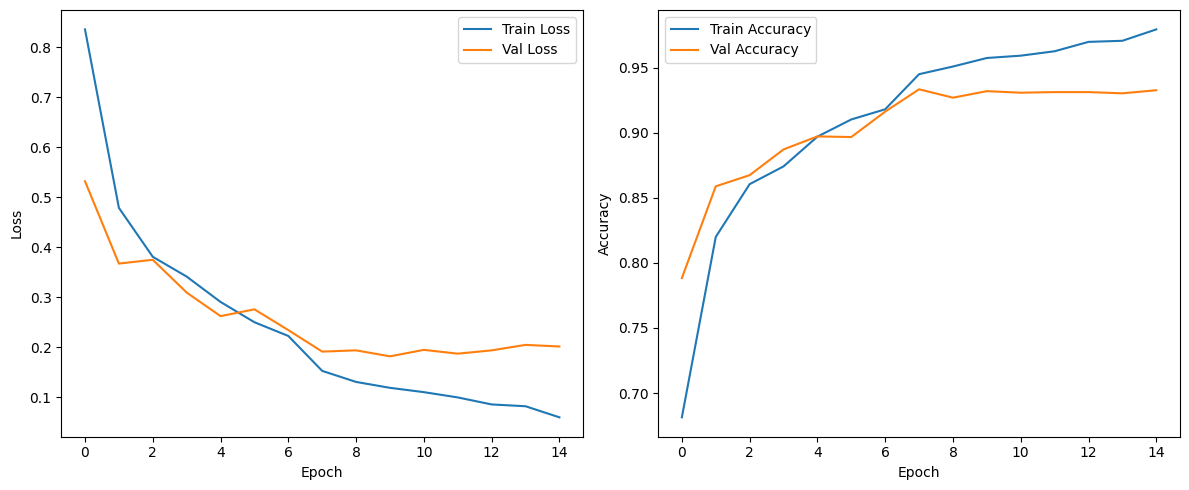

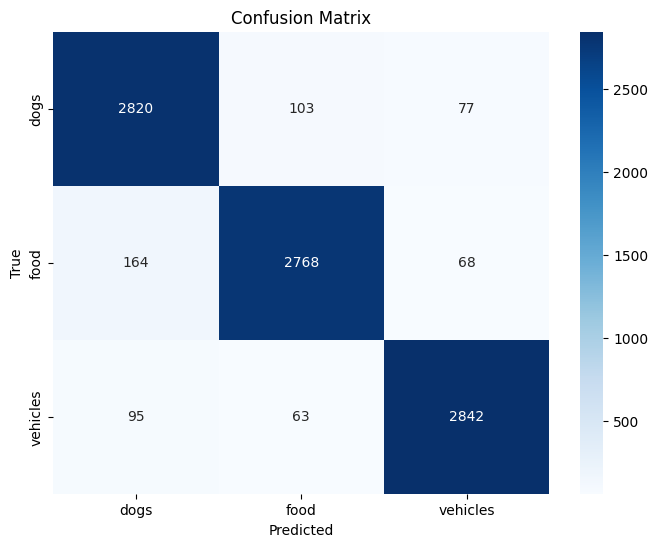

Classification Report:
              precision    recall  f1-score   support

        dogs       0.92      0.94      0.93      3000
        food       0.94      0.92      0.93      3000
    vehicles       0.95      0.95      0.95      3000

    accuracy                           0.94      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.94      0.94      0.94      9000


Training with: Init=xavier, Optimizer=SGD, Batch=128


  7%|▋         | 1/15 [00:55<12:55, 55.38s/it]

Epoch 1/15: Train Loss: 0.6298, Train Acc: 0.7747 | Val Loss: 0.4263, Val Acc: 0.8336, Time: 55.38 sec


 13%|█▎        | 2/15 [01:52<12:10, 56.23s/it]

Epoch 2/15: Train Loss: 0.3472, Train Acc: 0.8661 | Val Loss: 0.3128, Val Acc: 0.8817, Time: 56.82 sec


...

Epoch 13/15: Train Loss: 0.0116, Train Acc: 0.9965 | Val Loss: 0.2584, Val Acc: 0.9429, Time: 54.11 sec


 93%|█████████▎| 14/15 [13:11<00:55, 55.40s/it]

Epoch 14/15: Train Loss: 0.0082, Train Acc: 0.9976 | Val Loss: 0.2775, Val Acc: 0.9410, Time: 55.92 sec


100%|██████████| 15/15 [14:09<00:00, 56.60s/it]

Epoch 15/15: Train Loss: 0.0053, Train Acc: 0.9985 | Val Loss: 0.2743, Val Acc: 0.9419, Time: 57.10 sec


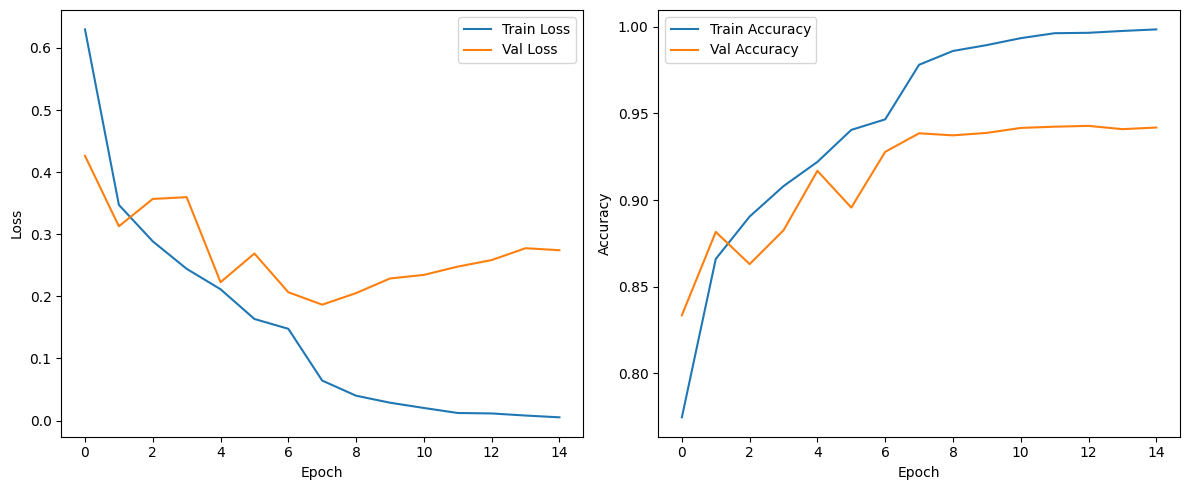

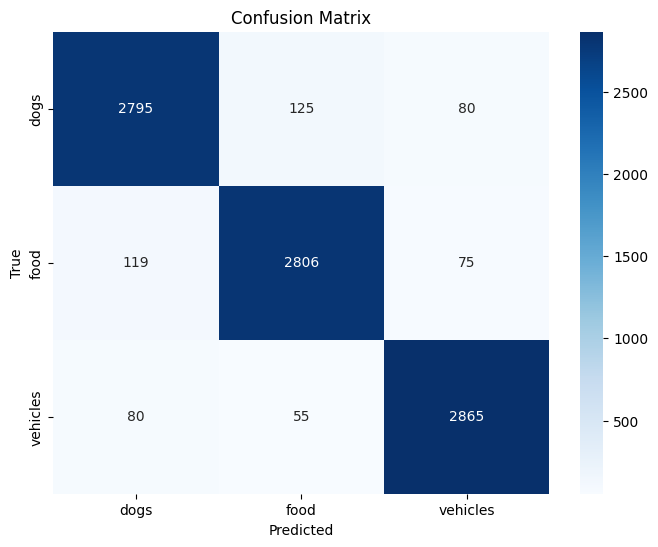

Classification Report:
              precision    recall  f1-score   support

        dogs       0.93      0.93      0.93      3000
        food       0.94      0.94      0.94      3000
    vehicles       0.95      0.95      0.95      3000

    accuracy                           0.94      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.94      0.94      0.94      9000


Training with: Init=xavier, Optimizer=Adam, Batch=64


  7%|▋         | 1/15 [01:00<14:07, 60.56s/it]

Epoch 1/15: Train Loss: 1.9727, Train Acc: 0.5138 | Val Loss: 0.7086, Val Acc: 0.6260, Time: 60.56 sec


 13%|█▎        | 2/15 [02:00<12:58, 59.92s/it]

Epoch 2/15: Train Loss: 0.7108, Train Acc: 0.7055 | Val Loss: 0.6152, Val Acc: 0.7821, Time: 59.47 sec


...

Epoch 13/15: Train Loss: 0.4310, Train Acc: 0.8373 | Val Loss: 0.4305, Val Acc: 0.8605, Time: 59.94 sec


 93%|█████████▎| 14/15 [13:44<00:58, 58.89s/it]

Epoch 14/15: Train Loss: 0.4068, Train Acc: 0.8499 | Val Loss: 0.4194, Val Acc: 0.8643, Time: 57.79 sec


100%|██████████| 15/15 [14:43<00:00, 58.87s/it]

Epoch 15/15: Train Loss: 0.3763, Train Acc: 0.8624 | Val Loss: 0.3944, Val Acc: 0.8702, Time: 58.29 sec


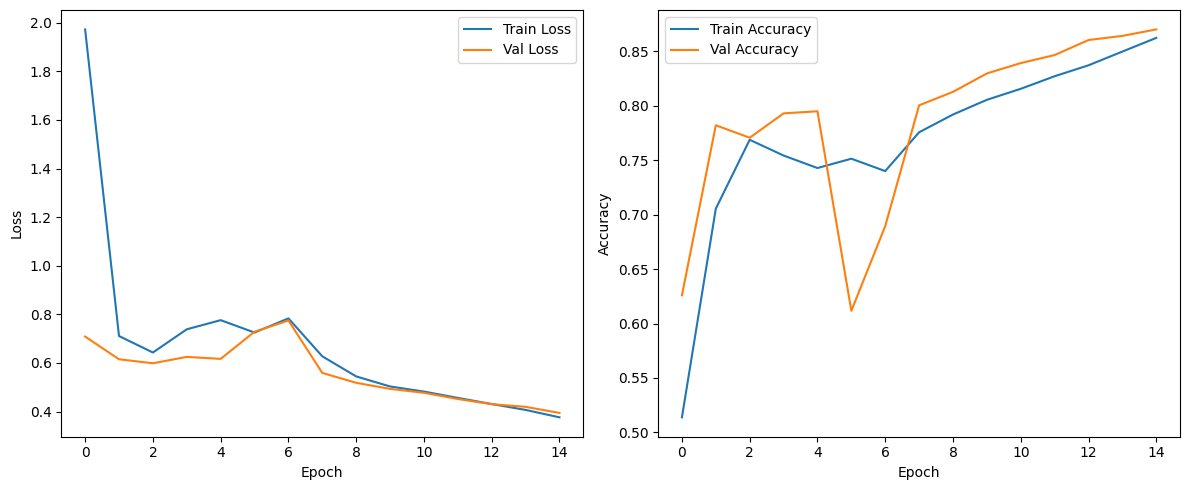

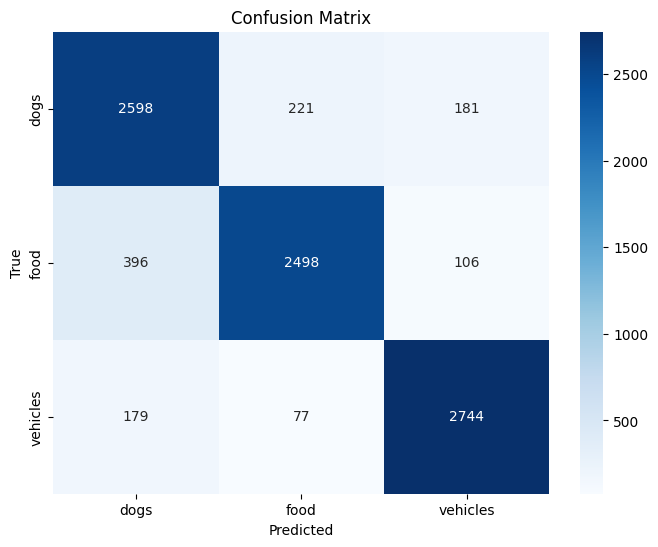

Classification Report:
              precision    recall  f1-score   support

        dogs       0.82      0.87      0.84      3000
        food       0.89      0.83      0.86      3000
    vehicles       0.91      0.91      0.91      3000

    accuracy                           0.87      9000
   macro avg       0.87      0.87      0.87      9000
weighted avg       0.87      0.87      0.87      9000


Training with: Init=xavier, Optimizer=Adam, Batch=128


  7%|▋         | 1/15 [00:56<13:17, 56.94s/it]

Epoch 1/15: Train Loss: 3.3661, Train Acc: 0.4322 | Val Loss: 0.8886, Val Acc: 0.5948, Time: 56.94 sec


 13%|█▎        | 2/15 [01:52<12:10, 56.19s/it]

Epoch 2/15: Train Loss: 0.6831, Train Acc: 0.7179 | Val Loss: 0.7359, Val Acc: 0.7083, Time: 55.66 sec


...

Epoch 13/15: Train Loss: 0.1990, Train Acc: 0.9306 | Val Loss: 0.2785, Val Acc: 0.9136, Time: 56.31 sec


 93%|█████████▎| 14/15 [13:22<00:57, 57.24s/it]

Epoch 14/15: Train Loss: 0.1913, Train Acc: 0.9327 | Val Loss: 0.2632, Val Acc: 0.9176, Time: 55.91 sec


100%|██████████| 15/15 [14:17<00:00, 57.18s/it]

Epoch 15/15: Train Loss: 0.1661, Train Acc: 0.9413 | Val Loss: 0.2381, Val Acc: 0.9271, Time: 55.49 sec


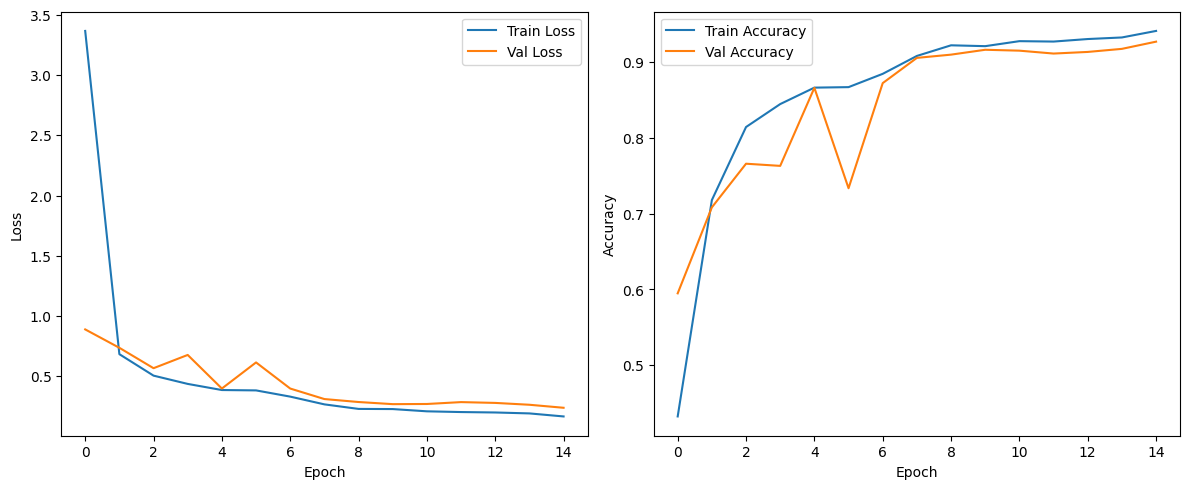

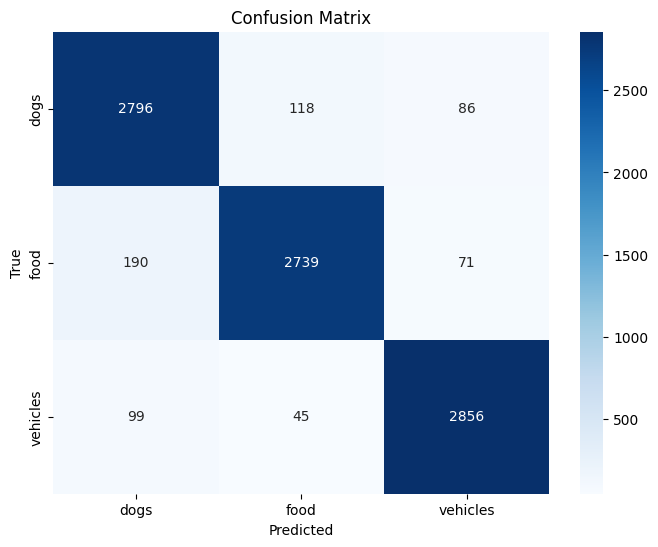

Classification Report:
              precision    recall  f1-score   support

        dogs       0.91      0.93      0.92      3000
        food       0.94      0.91      0.93      3000
    vehicles       0.95      0.95      0.95      3000

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000


Training with: Init=he, Optimizer=SGD, Batch=64


  7%|▋         | 1/15 [00:52<12:16, 52.60s/it]

Epoch 1/15: Train Loss: 0.6622, Train Acc: 0.7713 | Val Loss: 0.4190, Val Acc: 0.8426, Time: 52.60 sec


 13%|█▎        | 2/15 [01:44<11:21, 52.41s/it]

Epoch 2/15: Train Loss: 0.3850, Train Acc: 0.8543 | Val Loss: 0.3543, Val Acc: 0.8645, Time: 52.27 sec


...

Epoch 13/15: Train Loss: 0.0127, Train Acc: 0.9959 | Val Loss: 0.2885, Val Acc: 0.9340, Time: 53.70 sec


 93%|█████████▎| 14/15 [12:23<00:53, 53.47s/it]

Epoch 14/15: Train Loss: 0.0147, Train Acc: 0.9953 | Val Loss: 0.2780, Val Acc: 0.9367, Time: 52.38 sec


100%|██████████| 15/15 [13:17<00:00, 53.14s/it]

Epoch 15/15: Train Loss: 0.0087, Train Acc: 0.9971 | Val Loss: 0.2834, Val Acc: 0.9371, Time: 53.37 sec


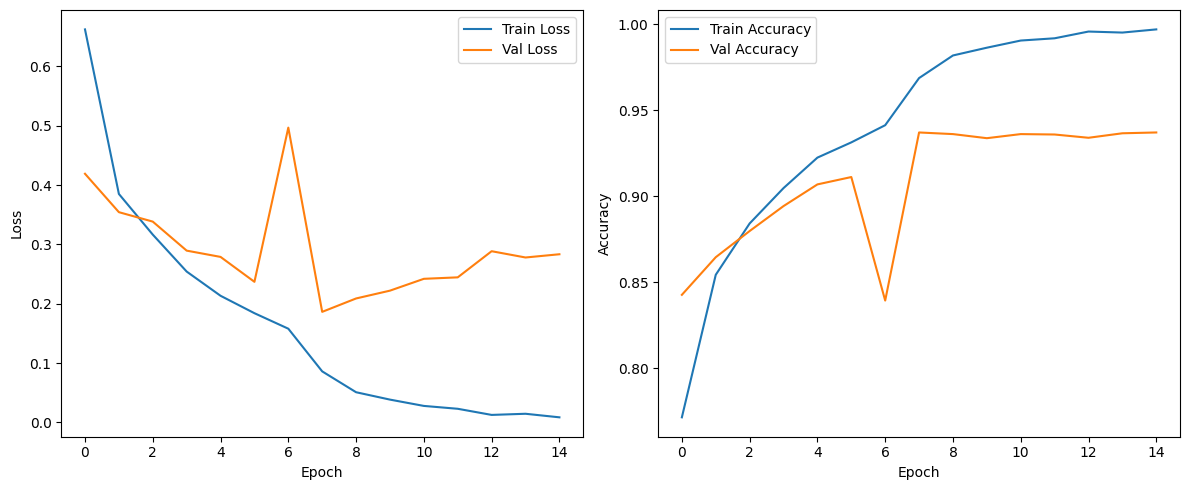

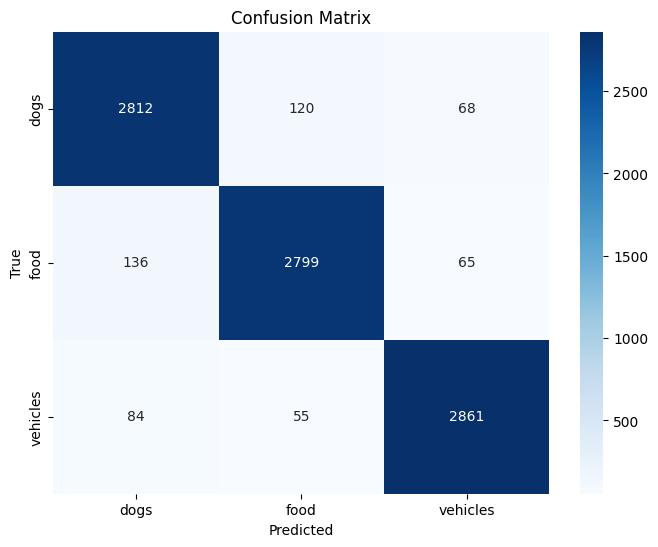

Classification Report:
              precision    recall  f1-score   support

        dogs       0.93      0.94      0.93      3000
        food       0.94      0.93      0.94      3000
    vehicles       0.96      0.95      0.95      3000

    accuracy                           0.94      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.94      0.94      0.94      9000


Training with: Init=he, Optimizer=SGD, Batch=128


  7%|▋         | 1/15 [00:56<13:13, 56.66s/it]

Epoch 1/15: Train Loss: 0.6590, Train Acc: 0.7404 | Val Loss: 0.4352, Val Acc: 0.8333, Time: 56.66 sec


 13%|█▎        | 2/15 [01:51<12:05, 55.77s/it]

Epoch 2/15: Train Loss: 0.3622, Train Acc: 0.8623 | Val Loss: 0.4758, Val Acc: 0.8271, Time: 55.15 sec


...

Epoch 13/15: Train Loss: 0.0047, Train Acc: 0.9990 | Val Loss: 0.3104, Val Acc: 0.9348, Time: 53.37 sec


 93%|█████████▎| 14/15 [12:42<00:53, 53.61s/it]

Epoch 14/15: Train Loss: 0.0037, Train Acc: 0.9990 | Val Loss: 0.3264, Val Acc: 0.9355, Time: 53.45 sec


100%|██████████| 15/15 [13:35<00:00, 54.38s/it]

Epoch 15/15: Train Loss: 0.0021, Train Acc: 0.9998 | Val Loss: 0.3275, Val Acc: 0.9350, Time: 53.12 sec


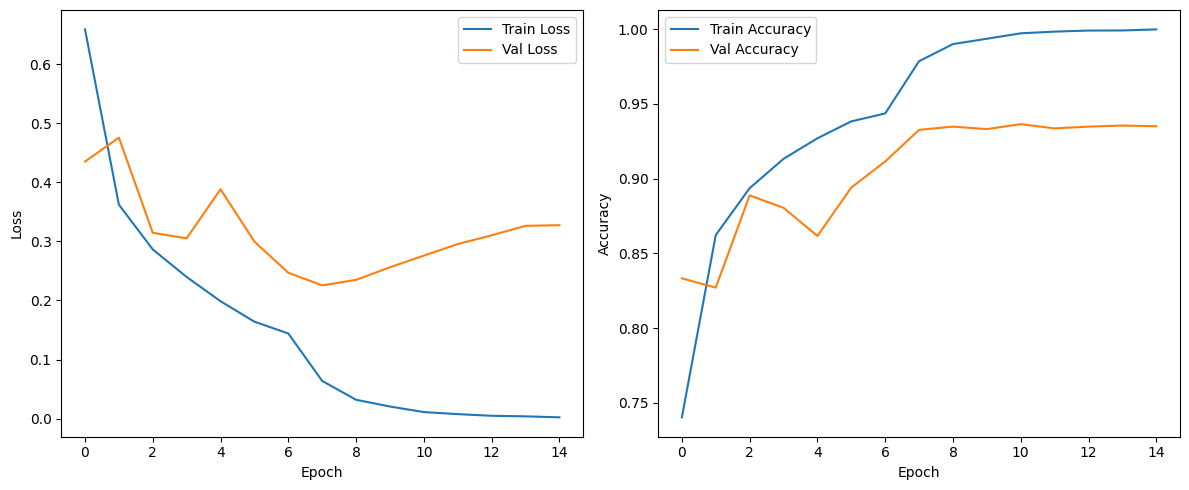

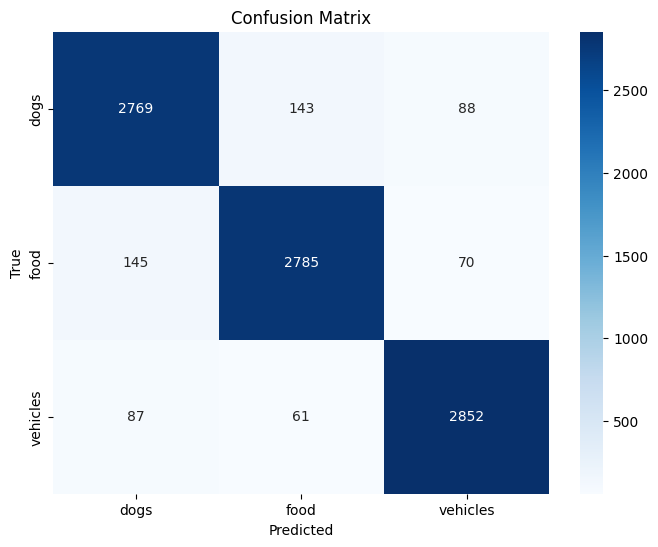

Classification Report:
              precision    recall  f1-score   support

        dogs       0.92      0.92      0.92      3000
        food       0.93      0.93      0.93      3000
    vehicles       0.95      0.95      0.95      3000

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000


Training with: Init=he, Optimizer=Adam, Batch=64


  7%|▋         | 1/15 [00:58<13:37, 58.41s/it]

Epoch 1/15: Train Loss: 1.9896, Train Acc: 0.5327 | Val Loss: 0.7874, Val Acc: 0.5500, Time: 58.41 sec


 13%|█▎        | 2/15 [01:56<12:37, 58.25s/it]

Epoch 2/15: Train Loss: 0.7443, Train Acc: 0.6481 | Val Loss: 0.6719, Val Acc: 0.7052, Time: 58.13 sec


...

Epoch 13/15: Train Loss: 0.3458, Train Acc: 0.8730 | Val Loss: 0.4185, Val Acc: 0.8621, Time: 61.36 sec


 93%|█████████▎| 14/15 [14:07<01:01, 61.06s/it]

Epoch 14/15: Train Loss: 0.3340, Train Acc: 0.8808 | Val Loss: 0.3819, Val Acc: 0.8769, Time: 60.60 sec


100%|██████████| 15/15 [15:09<00:00, 60.60s/it]

Epoch 15/15: Train Loss: 0.3115, Train Acc: 0.8909 | Val Loss: 0.3642, Val Acc: 0.8855, Time: 61.64 sec


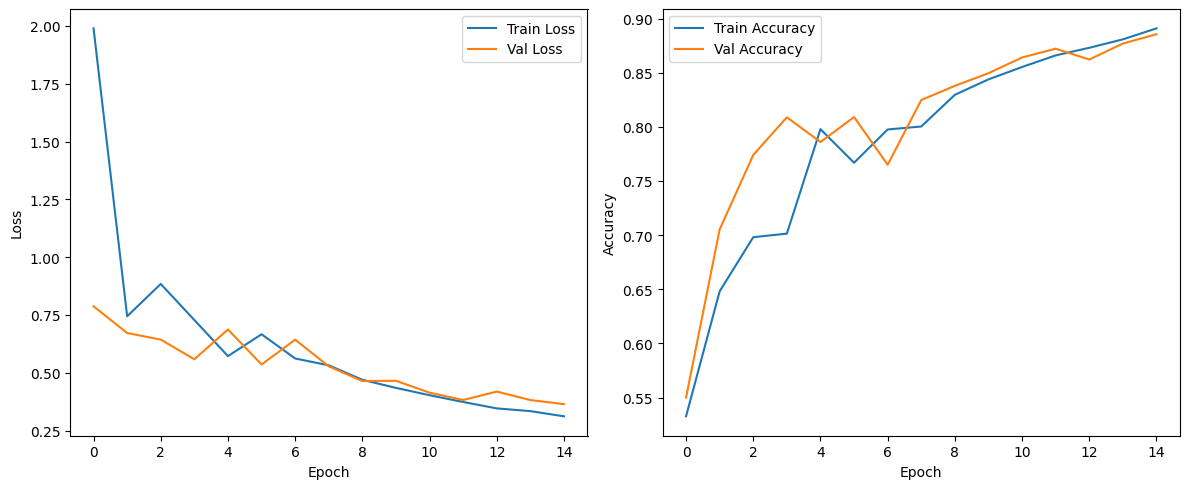

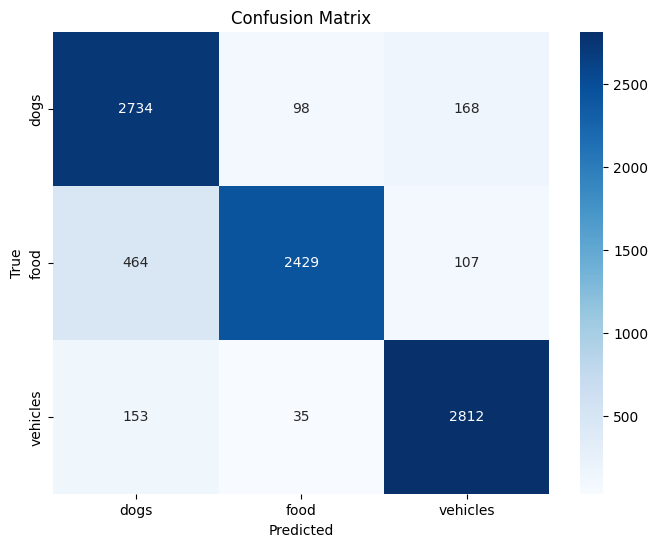

Classification Report:
              precision    recall  f1-score   support

        dogs       0.82      0.91      0.86      3000
        food       0.95      0.81      0.87      3000
    vehicles       0.91      0.94      0.92      3000

    accuracy                           0.89      9000
   macro avg       0.89      0.89      0.89      9000
weighted avg       0.89      0.89      0.89      9000


Training with: Init=he, Optimizer=Adam, Batch=128


  7%|▋         | 1/15 [01:01<14:18, 61.35s/it]

Epoch 1/15: Train Loss: 2.8191, Train Acc: 0.5043 | Val Loss: 0.8631, Val Acc: 0.5431, Time: 61.35 sec


 13%|█▎        | 2/15 [02:02<13:13, 61.01s/it]

Epoch 2/15: Train Loss: 0.7016, Train Acc: 0.6213 | Val Loss: 0.5676, Val Acc: 0.7800, Time: 60.77 sec


...

Epoch 13/15: Train Loss: 0.1966, Train Acc: 0.9292 | Val Loss: 0.2375, Val Acc: 0.9124, Time: 56.78 sec


 93%|█████████▎| 14/15 [13:30<00:56, 56.77s/it]

Epoch 14/15: Train Loss: 0.1857, Train Acc: 0.9331 | Val Loss: 0.2208, Val Acc: 0.9195, Time: 57.01 sec


100%|██████████| 15/15 [14:27<00:00, 57.85s/it]

Epoch 15/15: Train Loss: 0.1639, Train Acc: 0.9407 | Val Loss: 0.2162, Val Acc: 0.9212, Time: 57.12 sec


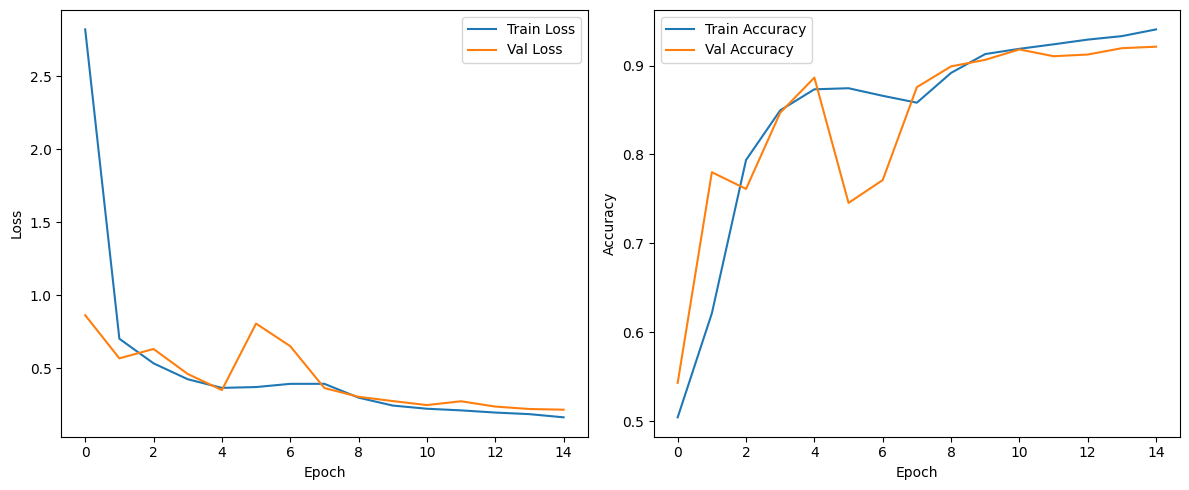

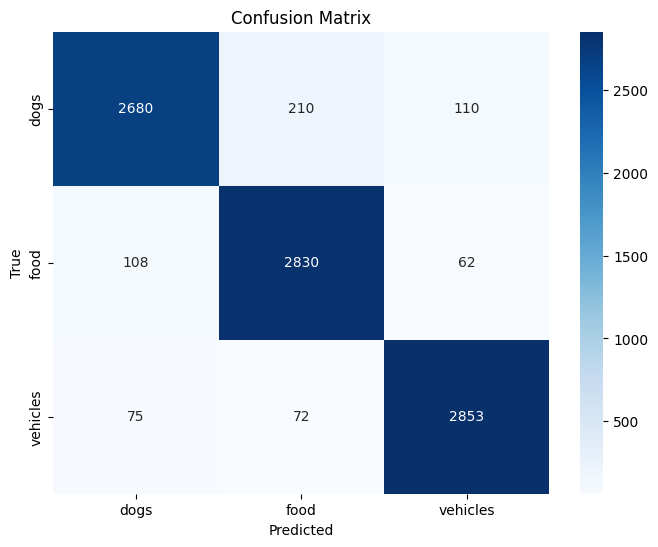

Classification Report:
              precision    recall  f1-score   support

        dogs       0.94      0.89      0.91      3000
        food       0.91      0.94      0.93      3000
    vehicles       0.94      0.95      0.95      3000

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000



In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
# epochs = 1
init_methods = ['xavier', 'he']
# # init_methods = ['xavier']
batch_sizes = [64, 128]
vgg_train_acc = {}
# results = {}
vgg_history = results[key]['vggnet_history']
best_model_params = ""
best_model_acc = 0.0
best_history = None
best_cm = None
best_report = None
epochs = 15
for init_method in init_methods:
    for opt_name in ['SGD', 'Adam']:
        for batch_size in batch_sizes:
            print(f"\nTraining with: Init={init_method}, Optimizer={opt_name}, Batch={batch_size}")

            model = VGG16ImprovedModel(num_classes=3, init_method=init_method).to(device)

            if opt_name == 'SGD':
                optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            else:
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
            model_name_prefix = 'a1_part2_sarayusi_vishalim_best_vgg_model.pth'
            model_params = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"

            # Train the model
            history = train_model(
                model, train_loader, val_loader, criterion, optimizer,
                model_name_prefix, scheduler=scheduler, num_epochs=epochs, device=device
            )

            # Evaluate on test set
            test_loss, test_acc, test_preds, test_labels = evaluate_model(model, test_loader, criterion, device)

            key = model_params
            results[key] = {
                'vggnet_history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }

            # Save best model
            if history['best_acc'] > best_model_acc:
                best_model_acc = history['best_acc']
                best_model_params = model_params
                best_history = history
                best_cm = results[key]['cm']
                best_report = results[key]['report']
                vgg_train_acc = results[key]['vggnet_history']
                torch.save(model.state_dict(), model_name_prefix)

            # Plot for this run
            plot_history(history)
            plot_confusion_matrix(results[key]['cm'], classes)
            print("Classification Report:")
            print(results[key]['report'])


In [59]:
print(f"Best model's parameters: {best_model_params}, Best Accuracy: {best_model_acc}")
 # best_model_acc = history['best_acc']
 #                best_model_params = model_params
 #                best_history = history
 #                best_cm = results[key]['cm']
 #                best_report = results[key]['report']
print(best_report)

vgg_history = results[key]['vggnet_history']
# print(vgg_history)
best_model = VGG16ImprovedModel(num_classes=3).to(device)

Best model's parameters: init_xavier_opt_SGD_batch_128, Best Accuracy: 0.9428571428571428
              precision    recall  f1-score   support

        dogs       0.93      0.93      0.93      3000
        food       0.94      0.94      0.94      3000
    vehicles       0.95      0.95      0.95      3000

    accuracy                           0.94      9000
   macro avg       0.94      0.94      0.94      9000
weighted avg       0.94      0.94      0.94      9000



VGG Improved Model Evaluation Results
Test Accuracy: 0.9043333333333333
Test Loss: 0.40568381140298315


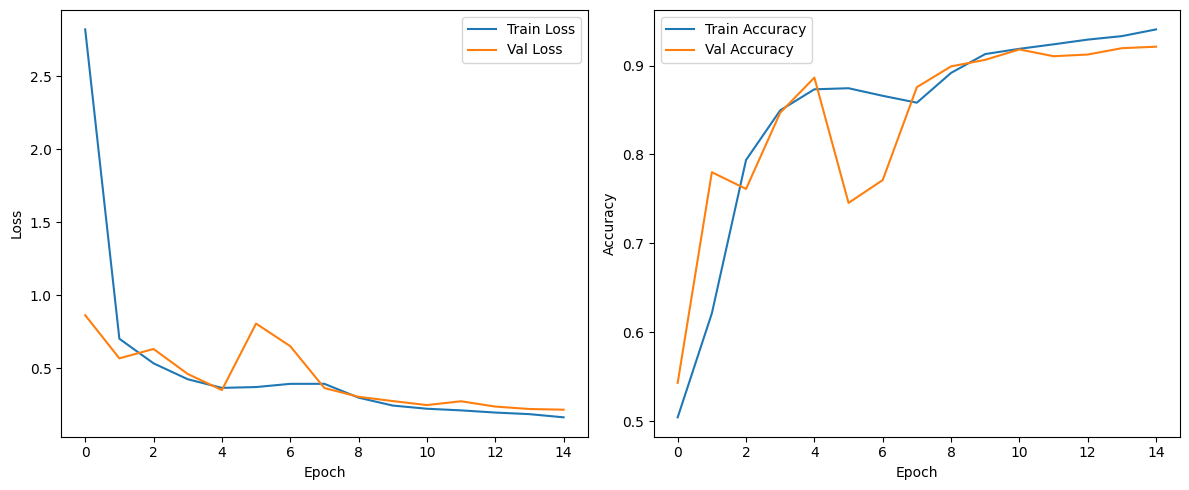

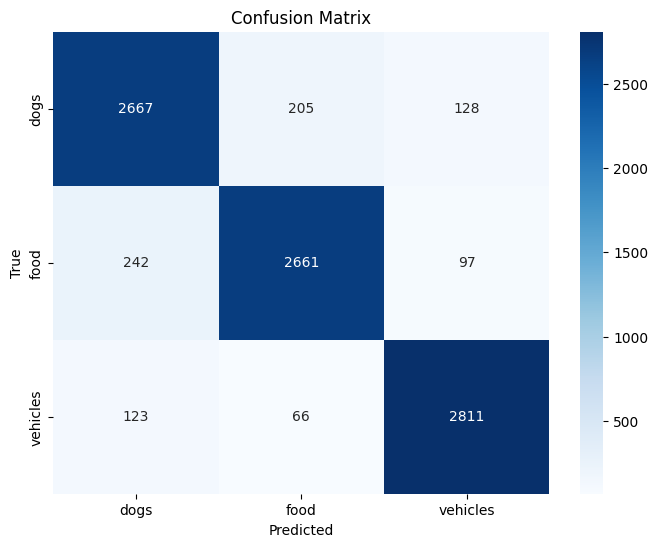

Classification Report:
              precision    recall  f1-score   support

        dogs       0.88      0.89      0.88      3000
        food       0.91      0.89      0.90      3000
    vehicles       0.93      0.94      0.93      3000

    accuracy                           0.90      9000
   macro avg       0.90      0.90      0.90      9000
weighted avg       0.90      0.90      0.90      9000



In [73]:
best_model.load_state_dict(torch.load('a1_part2_sarayusi_vishalim_best_vgg_model.pth'))
test_loss, test_acc, test_preds, test_labels = evaluate_model(
                best_model, test_loader, criterion, device
            )
            
# Save results
key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
results[key] = {
                'history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }

# Plot results
print("==========================================")
print("VGG Improved Model Evaluation Results")
print("==========================================")
print(f"Test Accuracy: {results[key] ['test_acc']}")
print(f"Test Loss: {results[key] ['test_loss']}")
plot_history(history)
plot_confusion_matrix(results[key]['cm'], classes)
print("Classification Report:")
print(results[key]['report'])

From the precision and recall scores, we can say that the accuracy value stands valid as these scores are almost the same meaning the model is able to generalize well. It more accurately predicts vechicles when compared to other two classes.

From the confusion matrix, looks like the model very often gets confused while trying to classify dogs and misclassifies them as food. 

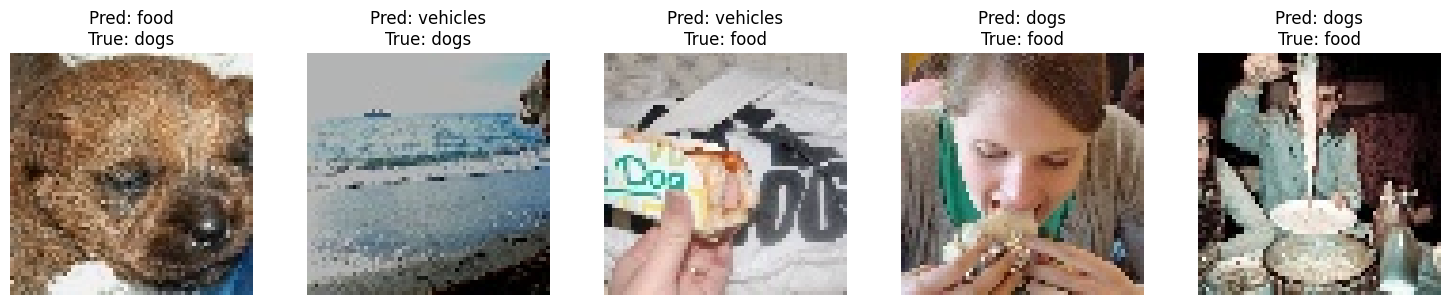

In [74]:
show_misclassified(best_model, test_loader, classes)

## Step 3: Implementing ResNet

1. Implement residual blocks of ResNet.

In [76]:
import torch.nn as nn
import torch

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)

        return out


In [77]:
import torch
import torch.nn as nn
import torch.nn.init as init

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = downsample

    def forward(self, x):
        identity = x
        
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10, init_method='xavier'):  # Add init_method here
        super(ResNet18, self).__init__()
        
        self.in_channels = 64
        self.init_method = init_method  # Save method

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 2)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._initialize_weights(init_method)  # Call init function

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def _initialize_weights(self, method='xavier'):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.xavier_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, 0, 0.01)
                init.constant_(m.bias, 0)




Training with: Init=xavier, Optimizer=Adam, Batch=64


  7%|▋         | 1/15 [00:33<07:48, 33.47s/it]

Epoch 1/15: Train Loss: 0.4418, Train Acc: 0.8293 | Val Loss: 0.4429, Val Acc: 0.8383, Time: 33.47 sec


 13%|█▎        | 2/15 [01:05<07:05, 32.72s/it]

Epoch 2/15: Train Loss: 0.3250, Train Acc: 0.8771 | Val Loss: 0.3215, Val Acc: 0.8814, Time: 32.19 sec


...

Epoch 13/15: Train Loss: 0.0136, Train Acc: 0.9955 | Val Loss: 0.3321, Val Acc: 0.9302, Time: 32.26 sec


 93%|█████████▎| 14/15 [07:42<00:32, 32.68s/it]

Epoch 14/15: Train Loss: 0.0117, Train Acc: 0.9962 | Val Loss: 0.3514, Val Acc: 0.9324, Time: 32.64 sec


100%|██████████| 15/15 [08:14<00:00, 32.94s/it]

Epoch 15/15: Train Loss: 0.0060, Train Acc: 0.9985 | Val Loss: 0.3489, Val Acc: 0.9300, Time: 31.97 sec


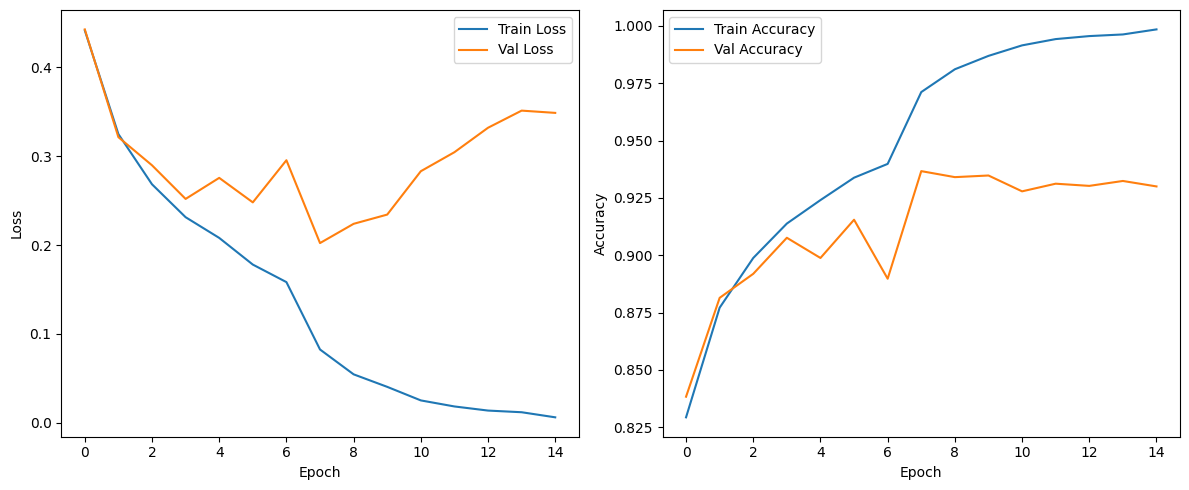

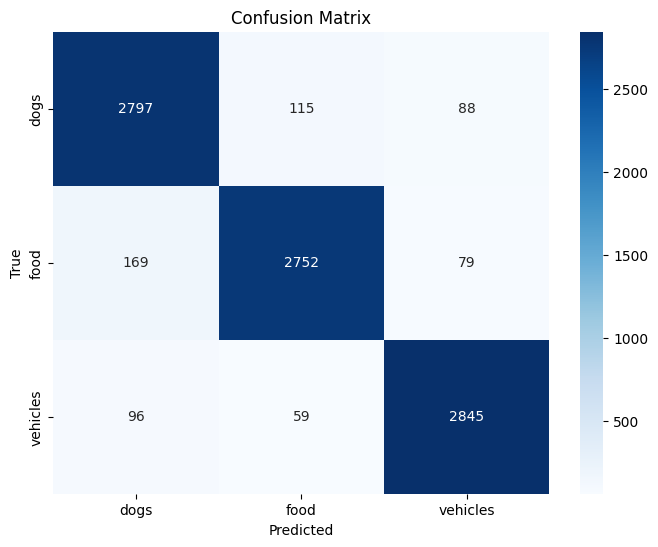

Classification Report:
              precision    recall  f1-score   support

        dogs       0.91      0.93      0.92      3000
        food       0.94      0.92      0.93      3000
    vehicles       0.94      0.95      0.95      3000

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000



In [89]:
criterion = nn.CrossEntropyLoss()
# init_xavier_opt_SGD_batch_128
epochs = 15
init_methods = ['xavier']

batch_sizes = [64]

results = {}

for init_method in init_methods:
    for opt_name in ['Adam']:
        for batch_size in batch_sizes:
            print(f"\nTraining with: Init={init_method}, Optimizer={opt_name}, Batch={batch_size}")
            
            model = ResNet18(num_classes=3, init_method=init_method)
            optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            if opt_name == 'SGD':
                optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
            elif opt_name == 'Adam':
                optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
            
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
            
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
            model_name_prefix = "a1_part2_sarayusi_vishalim_best_resnet_model.pth"
            history = train_model(
                model, train_loader, val_loader, criterion, optimizer, model_name_prefix,
                scheduler=scheduler, num_epochs=epochs, device=device, 
            )
            
            test_loss, test_acc, test_preds, test_labels = evaluate_model(
                model, test_loader, criterion, device
            )
            
            key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
            results[key] = {
                'resnet_history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }
            
            # Plot results
            plot_history(history)
            plot_confusion_matrix(results[key]['cm'], classes)
            print("Classification Report:")
            print(results[key]['report'])
        

resnet_train_acc = results[key]['resnet_history']

# Save best model
best_model = ResNet18(num_classes=3).to(device)
best_model.load_state_dict(torch.load('a1_part2_sarayusi_vishalim_best_resnet_model.pth'))
# torch.save(best_model.state_dict(), 'final_resnet_model.pth')


Resnet Model Evaluation Results
Test Accuracy: 0.9326666666666666
Test Loss: 0.3203659293136249


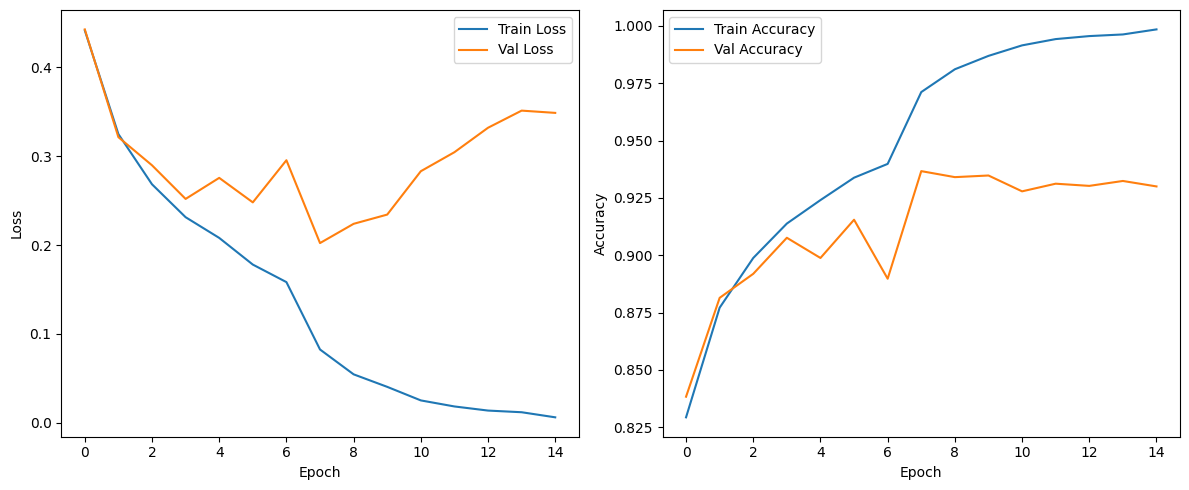

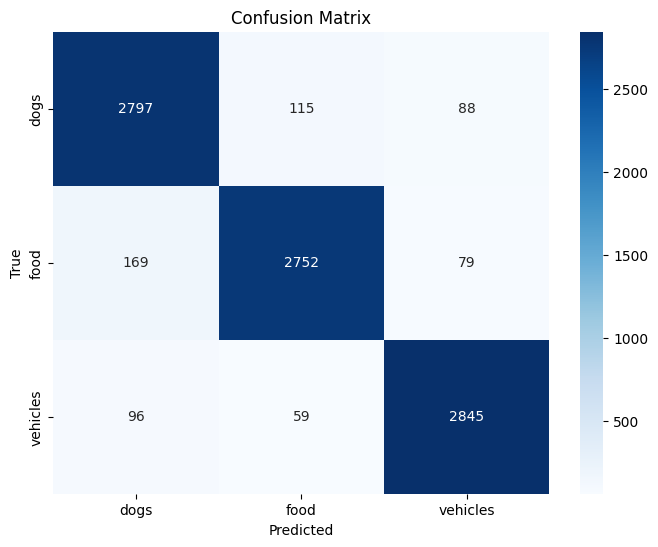

Classification Report:
              precision    recall  f1-score   support

        dogs       0.91      0.93      0.92      3000
        food       0.94      0.92      0.93      3000
    vehicles       0.94      0.95      0.95      3000

    accuracy                           0.93      9000
   macro avg       0.93      0.93      0.93      9000
weighted avg       0.93      0.93      0.93      9000



In [91]:
torch.save(model.state_dict(), model_name_prefix)

best_model.load_state_dict(torch.load('a1_part2_sarayusi_vishalim_best_resnet_model.pth'))
test_loss, test_acc, test_preds, test_labels = evaluate_model(
                best_model, test_loader, criterion, device
            )
            
# Save results
key = f"init_{init_method}_opt_{opt_name}_batch_{batch_size}"
results[key] = {
                'history': history,
                'test_acc': test_acc,
                'test_loss': test_loss,
                'cm': confusion_matrix(test_labels, test_preds),
                'report': classification_report(test_labels, test_preds, target_names=classes)
            }

# Plot results
print("==========================================")
print("Resnet Model Evaluation Results")
print("==========================================")
print(f"Test Accuracy: {results[key] ['test_acc']}")
print(f"Test Loss: {results[key] ['test_loss']}")
plot_history(history)
plot_confusion_matrix(results[key]['cm'], classes)
print("Classification Report:")
print(results[key]['report'])

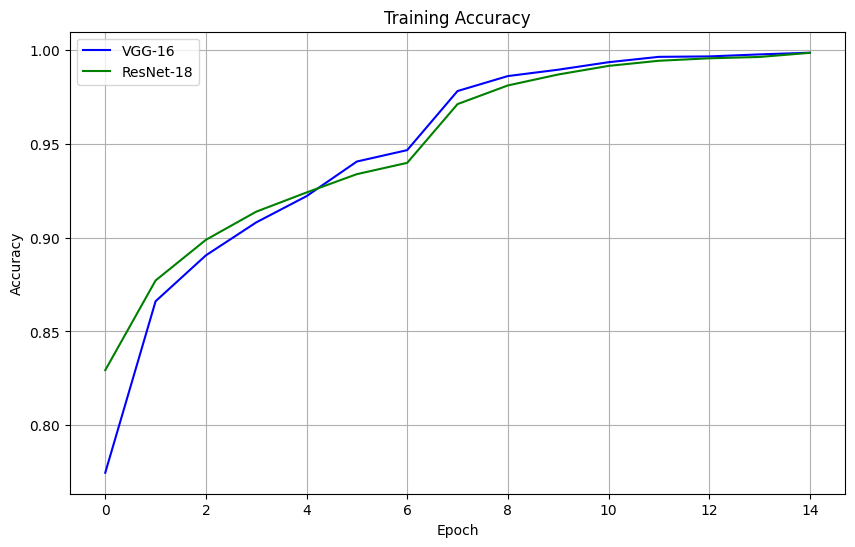

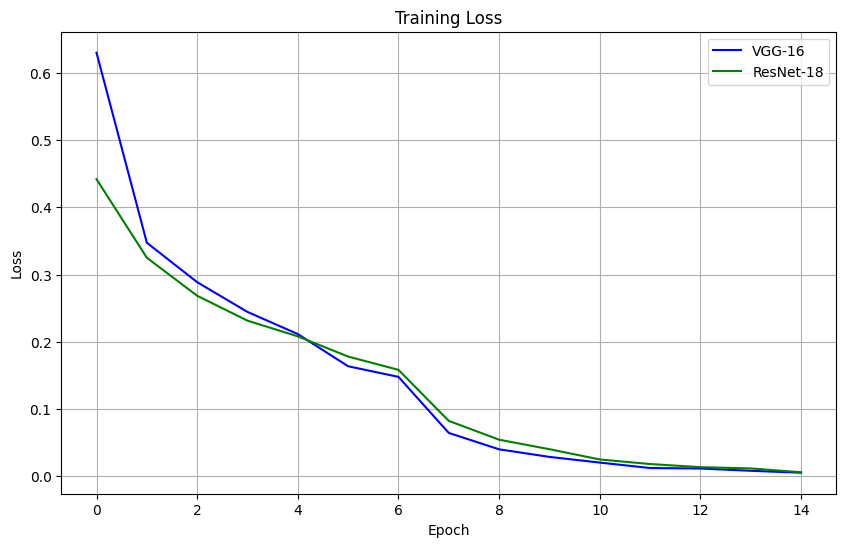

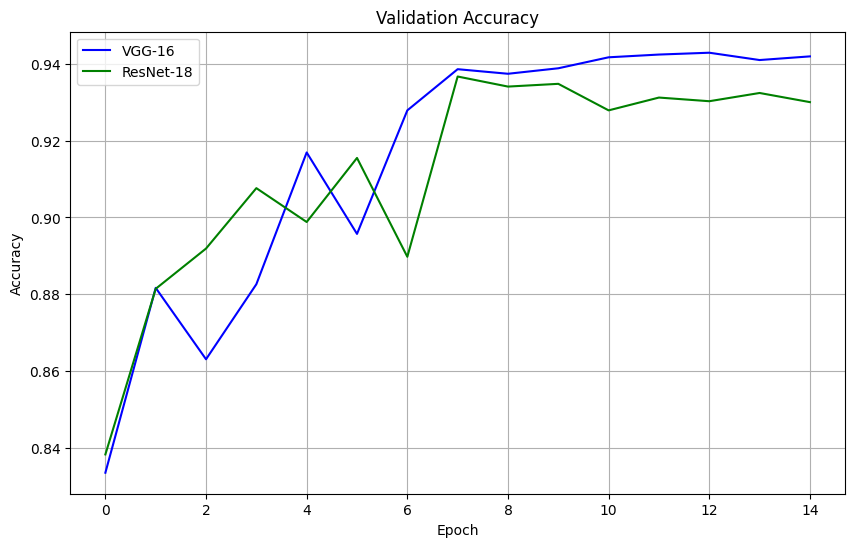

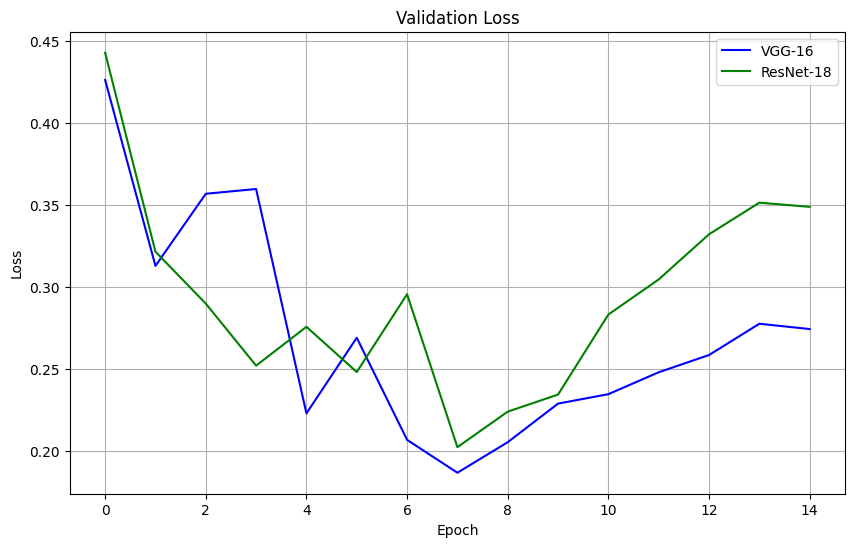

In [92]:
import matplotlib.pyplot as plt

def plot_comparison(metric_vgg, metric_resnet, title, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(metric_vgg, label='VGG-16', linestyle='-', color='blue')
    plt.plot(metric_resnet, label='ResNet-18', linestyle='-', color='green')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

# Example:
plot_comparison(vgg_train_acc['train_acc'], resnet_train_acc['train_acc'], "Training Accuracy", "Accuracy")
plot_comparison(vgg_train_acc['train_loss'], resnet_train_acc['train_loss'], "Training Loss", "Loss")

plot_comparison(vgg_train_acc['val_acc'], resnet_train_acc['val_acc'], "Validation Accuracy", "Accuracy")
plot_comparison(vgg_train_acc['val_loss'], resnet_train_acc['val_loss'], "Validation Loss", "Loss")


Comparing the performance of VGG and ResNet models, we can see that in terms of training, both the models learn to perform well although ResNet model's take comparitively lesser time per epoch. 

In terms of test evaluation, ResNet model has better test accuracy 93% when compared to VGG's best performing model 90%

## Step 4: Discussion and conclusion

1. Explain the theoretical concepts behind VGG and ResNet.

<span style='color:green'>### YOUR ANSWER ###</span>

### Visual Geometry Group Network (VGG):

- VGG is a deep convolutional neural network (CNN) that makes use of small convolutional filters and stack them together. 

- The network is made of multiple convolutional layers with 3×3 filters and stride 1, followed by 2×2 max pooling layers with stride 2.  After every convolutional layer, a ReLU activation is applied to introduce non-linearity. The final part of the network includes two or three fully connected layers, ending in a softmax output for classification.

- VGG-16 and VGG-19 (with 16 and 19 weight layers, respectively) demonstrated that increasing the depth of a CNN can significantly improve its performance on large-scale image classification tasks (like ImageNet).

- The downside of this architecture is computational complexity as it uses many parameters and is prone to vanishing gradients as the network grows deeper


### Residual Network (ResNet)

- ResNet is also deep convolutional neural network that makes use of convolutional layers wrapped in residual blocks.

- These residual (skip) connections allow the input of a layer to be added directly to the output of a deeper layer enabling gradients to flow more effectively through very deep networks, mitigating the vanishing gradient problem and making it feasible to train much deeper architectures than before

- The network preserves important information from earlier layers easily using skip connections. This feature helps the network reuse those features and generalize better.

- Some variants of ResNet make use of bottleneck blocks to minimize computation cost as the network grows deeper.
 
- Compared to VGG, ResNet models achieve better generalization and performance on deep learning tasks, and are less prone to degradation as depth increases. However, very deep ResNets can still be computationally expensive

2. Discuss the impact of regularization and optimization techniques.

<span style='color:green'>### YOUR ANSWER ###</span>

- To prevent overfitting, regularization techniques such as Dropout and Batch Normalization were integrated into the improved version of the VGGNet model. The base model, without these enhancements, achieved a respectable accuracy of 86%. However, after incorporating these regularization methods, the model demonstrated significantly better generalization, reaching an improved accuracy of 90%. Applied L2 regularization to penalize large weights.

- Implemented early stopping to ensure that the model doesn't get stuck in local minimum and not learn over a signficant preiod of time.  

- Experimented with different optimizers like Adam and SGD and observed that Adam performs better and accelerates the convergence faster when compared to SGD. Similarly tried xavier and he methods for weight initialization and noticed that 

- Additionally, a learning rate scheduler was applied to adjust the learning rate during training. This helped the model to prevent sudden drops in performance, allowing the model to fine-tune its weights more effectively during later epochs

3. Analyze the results, including all required graphs and metrics.

<span style='color:green'>### YOUR ANSWER ###</span>

Training the VGG base model resulted in 86% accuracy which is good performance given the model was trained for only 5 epochs. To improve the model's performance even further, including dropouts and batch normalization techniques futher improved the model's accuracy. 
By experimenting with different hyperparameters for the improved model, obtained the following results:

| Initialization | Optimizer | Batch Size | Validation Accuracy  | Avg. Time per Epoch (sec)|
|----------------|-----------|------------|----------------------|--------------------------|
|                                   VGG Improved Model                                      |
| xavier         | SGD       | 64         | 0.94                 | 55                       |
| xavier         | SGD       | 128        | 0.87                 | 55                       |
| xavier         | Adam      | 64         | 0.94                 | 58                       |
| xavier         | Adam      | 128        | 0.93                 | 57                       |
| he             | SGD       | 64         | 0.94                 | 53                       |
| he             | SGD       | 128        | 0.93                 | 54                       |
| he             | Adam      | 64         | 0.89                 | 60                       |
| he             | Adam      | 128        | 0.93                 | 57                       |
|                                   ResNet Model                                            |
| xavier         | Adam       | 64         | 0.93                 | 32                      |

From this table we can see that VGG model performed well for both xavier and he initializations but on average they tend to perform better when the weights were initialized using xavier method. 

![Train_Loss_Accuracy](vgg_eval.png "Train loss for VGG Model")
![Train_Loss_Accuracy](resnet_eval.png "Train loss for ResNet Model")
Comparing the optimizers used, SGD performed well in almost all the cases and Adam optimizers on the other hand, help the model learn quickly and more stabilized manner.

So, applying the best performing hyper parameters in VGG model to ResNet proved to be effective as the model attained test accuracy or 93% in less than half the time taken by VGG models. This could be attributed to the effective residual blocks

Although in the comparision plot of validation accuracy ResNet's performance is slighly lower than that of VGG the final model generalizes well during the inference phase

Here is comparision of confusion matrix by both the models:

VGGNet
![Confusion Matrix](vgg_cm.png "Confusion Matrix for VGG Model")


ResNet
![Confusion Matrix](resnet_cm.png "Confusion Matrix for ResNet Model")


Both the models struggle to correctly distinguish dogs as they are often mislabelled as food and vice versa. In VGGNet the count of misclassified values are in the range 200-250 whereas in ResNet model the values typically range between 100-170 which is a significant improvement

4. Summarize your findings and discuss the advantages of residual connections.

<span style='color:green'>### YOUR ANSWER ###</span>

### Summary
##### Base VGG Model:

The base VGG16 model (without regularization or optimization enhancements) achieved a baseline accuracy of 86% on the test set.

##### Improved VGG Model:

After incorporating regularization techniques like Dropout and Batch Normalization, in combination with Adam optimizer and learning rate scheduler, the performance of VGG improved significantly upto 94%

##### ResNet Model:

By applying the best performing hyperparameters to ResNet model on the same dataset, ResNet showed more stable training dynamics and faster convergence, often requiring fewer epochs to reach comparable or superior accuracy.

### Advantages of Residual Connections

- Residual connections address vanishing gradient problem by allowing gradients to flow directly through skip connections during backpropagation.

- Initial layer outputs are passed forward, allowing the network to reuse low-level features which becomes useful for tasks that require both fine and abstract features.

- Residual architectures combined with regularization generalize better than traditional CNNs as they allow deeper representations without overfitting.

- ResNet models outperform traditional deep CNNs (like VGG) in accuracy and training efficiency, particularly as network depth increases (e.g., ResNet-50, ResNet-101).

5. References.

<span style='color:green'>### YOUR ANSWER ###</span>

1. https://sahiltinky94.medium.com/know-about-vgg-model-and-implementation-using-pytorch-ca2c5ba4a1bf 
2. https://medium.com/analytics-vidhya/resnet-understand-and-implement-from-scratch-d0eb9725e0db
3. https://www.geeksforgeeks.org/residual-networks-resnet-deep-learning/
4. https://towardsdatascience.com/dropout-in-neural-networks-47a162d621d9/
5. https://www.kaggle.com/code/vishalimanip/a1-part2-resnet

Note: 

As we had issues with accessing CCR, we uploaded the dataset in Kaggle to utilize the computation resource for this assignment https://www.kaggle.com/code/vishalimanip/a1-part2-resnet

In [83]:
import json

with open('vgg_history.json', 'w') as f:
    json.dump(vgg_train_acc, f)


import json

with open('resnet_history.json', 'w') as f:
    json.dump(resnet_train_acc, f)
    

with open('vgg_history.json', 'r') as f:
    vgg_history = json.load(f)

with open('resnet_history.json', 'r') as f:
    resnet_history = json.load(f)

print(vgg_history)
print("=======================================")
print(resnet_history)

{'train_loss': [0.6297696975299291, 0.34724536316735405, 0.2886209612800961, 0.24435398652440027, 0.21145525519336972, 0.16359959051722572, 0.14780069114196867, 0.06444451532193593, 0.040090315973474865, 0.028830272864018167, 0.020368942574908337, 0.012264699496861015, 0.011550151096834313, 0.008179248894919597, 0.005295441260539172], 'val_loss': [0.42628685695784435, 0.31282779086203805, 0.3568356640565963, 0.35973616072109765, 0.2228244906380063, 0.2689909342357091, 0.2066872194835118, 0.18663029991445088, 0.2052582271326156, 0.22880150278409322, 0.23456237060683113, 0.24792559470449174, 0.25844343622525534, 0.27752459293320064, 0.2742923252355485], 'train_acc': [0.774702380952381, 0.8660714285714286, 0.8905357142857143, 0.9080952380952381, 0.9220833333333334, 0.9405357142857143, 0.9466071428571429, 0.9780952380952381, 0.9860714285714286, 0.9894642857142857, 0.993452380952381, 0.9963095238095238, 0.996547619047619, 0.9976190476190476, 0.9985119047619048], 'val_acc': [0.83357142857142